# Import Packages

In [1]:
import FlowCal

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import os
from tkinter.filedialog import askdirectory
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout
import pickle
from sklearn.metrics import auc
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import itertools

In [2]:
# EXTRACTED FROM: https://www.geeksforgeeks.org/dsa/how-to-check-if-a-given-point-lies-inside-a-polygon/

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

# Checking if a point is inside a polygon
def point_in_polygon(point, polygon):
    num_vertices = len(polygon)
    x, y = point.x, point.y
    inside = False

    # Store the first point in the polygon and initialize the second point
    p1 = polygon[0]

    # Loop through each edge in the polygon
    for i in range(1, num_vertices + 1):
        # Get the next point in the polygon
        p2 = polygon[i % num_vertices]

        # Check if the point is above the minimum y coordinate of the edge
        if y > min(p1.y, p2.y):
            # Check if the point is below the maximum y coordinate of the edge
            if y <= max(p1.y, p2.y):
                # Check if the point is to the left of the maximum x coordinate of the edge
                if x <= max(p1.x, p2.x):
                    # Calculate the x-intersection of the line connecting the point to the edge
                    x_intersection = (y - p1.y) * (p2.x - p1.x) / (p2.y - p1.y) + p1.x

                    # Check if the point is on the same line as the edge or to the left of the x-intersection
                    if p1.x == p2.x or x <= x_intersection:
                        # Flip the inside flag
                        inside = not inside

        # Store the current point as the first point for the next iteration
        p1 = p2

    # Return the value of the inside flag
    return inside

# Driver code
if __name__ == "__main__":
    # Define a point to test
    point = Point(150, 85)

    # Define a polygon
    polygon = [
        Point(186, 14),
        Point(186, 44),
        Point(175, 115),
        Point(175, 85)
    ]

    # Check if the point is inside the polygon
    if point_in_polygon(point, polygon):
        print("Point is inside the polygon")
    else:
        print("Point is outs")

Point is outs


# Beads Calibration

In [3]:
# 5 ug per 1 million cells

mainP2 = 'C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/MCT_CalibrationBeeds/' # Main experiment with increasing Ab concentrations

fls2 = os.listdir(mainP2)
flsFC2 = [fls2[i] for i in range(len(fls2)) if fls2[i][-3::] != 'PDF' and fls2[i] != 'Plots' and fls2[i] != 'Calibrate']

flsFC2

['a488 Beeds1 00220082 128.LMD',
 'a488 Beeds1 00220085 131.LMD',
 'a488 Beeds2 00220086 132.LMD',
 'a488 Beeds3 00220087 133.LMD',
 'a488 Beeds4 00220088 134.LMD']

In [4]:
datsb = {}
datsGt1b = {}
datsGt2b = {}
for i in range(len(flsFC2)):
    datsb[flsFC2[i]] = FlowCal.transform.to_rfi(FlowCal.io.FCSData(mainP2+flsFC2[i]))
    
    datsGt1b[flsFC2[i]] = FlowCal.gate.high_low(datsb[flsFC2[i]], channels=['FS INT LIN', 'FL1 INT LOG'])

    datsGt2b[flsFC2[i]] = FlowCal.gate.density2d(datsGt1b[flsFC2[i]],
                                channels=['FS INT LIN', 'FL1 INT LOG'],
                                gate_fraction=0.95,
                                full_output=True)

c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 112399)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 265263)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 266847)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 266955)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data se

<Figure size 640x480 with 0 Axes>

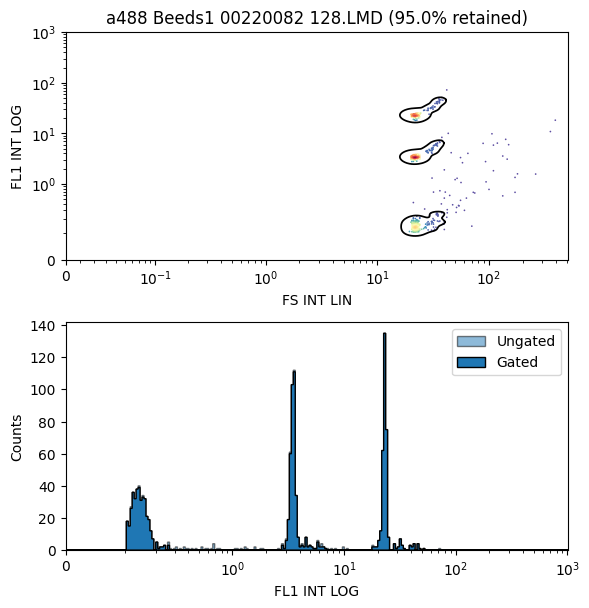

<Figure size 640x480 with 0 Axes>

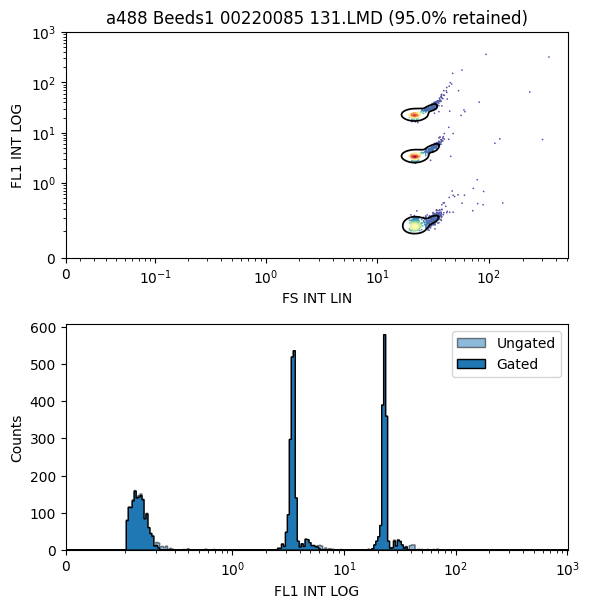

<Figure size 640x480 with 0 Axes>

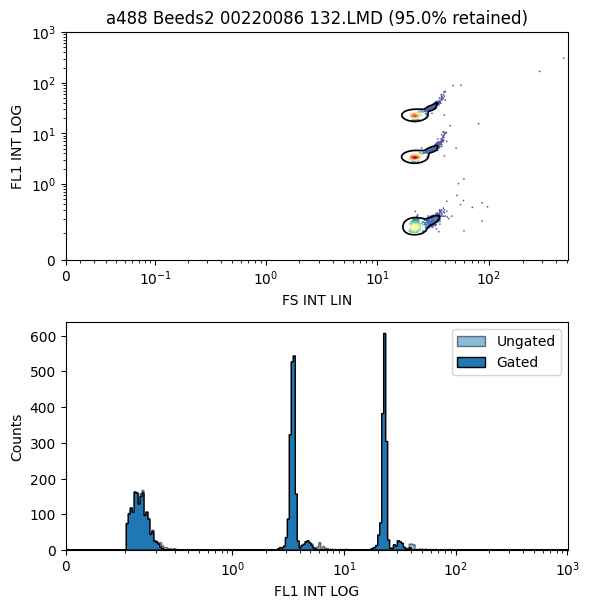

<Figure size 640x480 with 0 Axes>

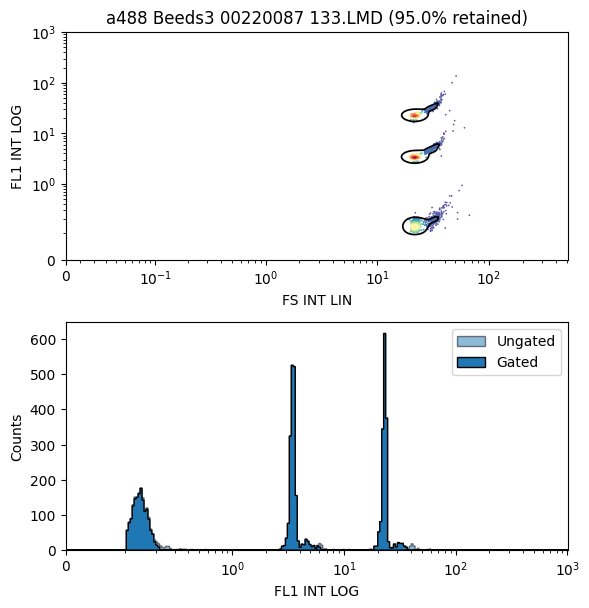

<Figure size 640x480 with 0 Axes>

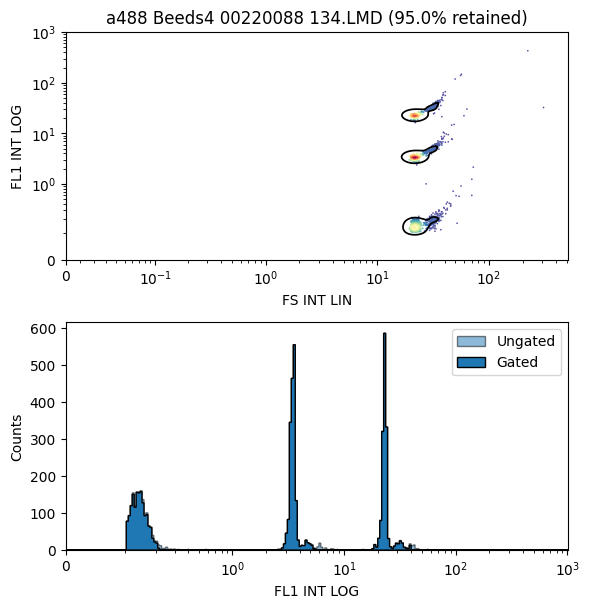

In [5]:
if os.path.isdir(mainP2+'Plots/') == False:
    os.mkdir(mainP2+'Plots/')

for i in range(len(flsFC2)):

    plt.ioff()

    fig = plt.figure()
    FlowCal.plot.density_and_hist(datsGt1b[flsFC2[i]],
                                gated_data=datsGt2b[flsFC2[i]].gated_data,
                                gate_contour=datsGt2b[flsFC2[i]].contour,
                                density_channels=['FS INT LIN', 'FL1 INT LOG'],
                                density_params={'mode':'scatter'},
                                hist_channels=['FL1 INT LOG'])
    plt.tight_layout()
    
    
    plt.savefig(mainP2+'Plots/'+flsFC2[i][0:-4]+'.png')
    plt.show()

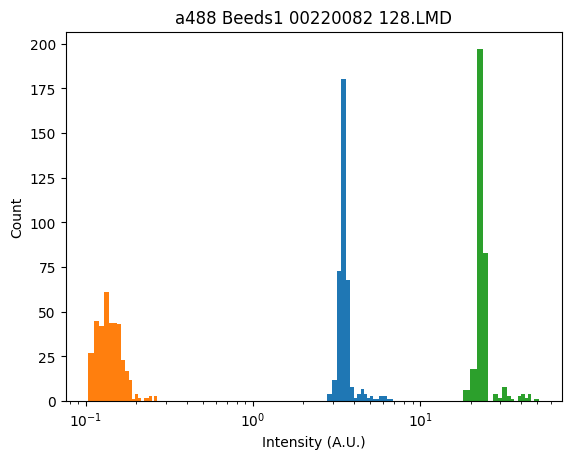

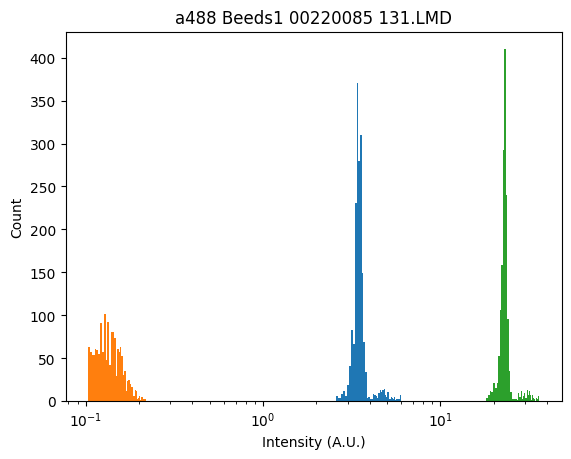

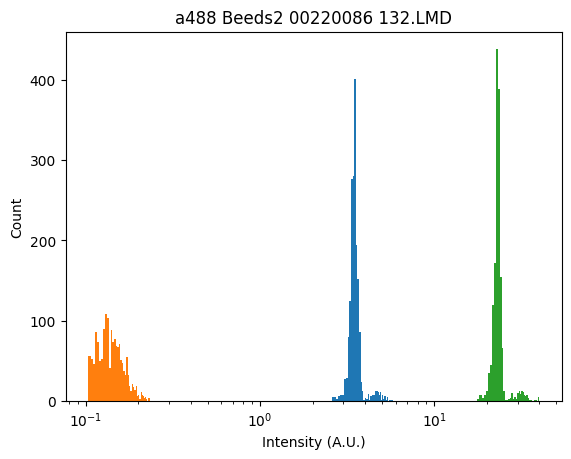

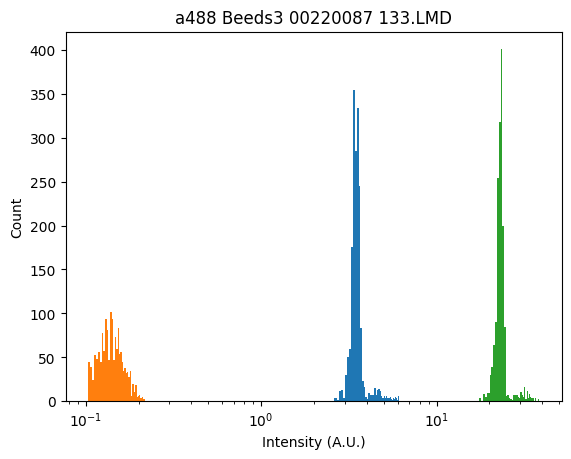

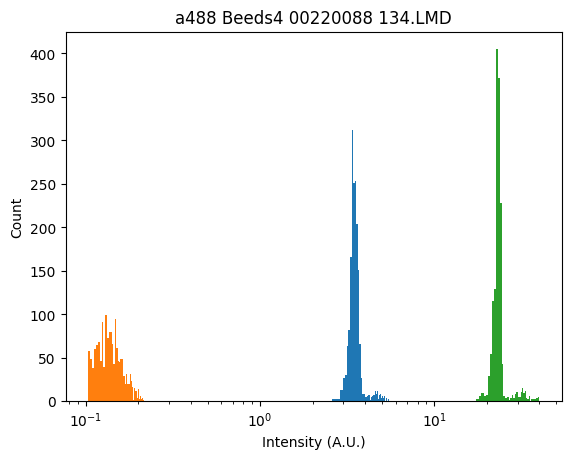

In [6]:
C6L = [flsFC2[i] for i in range(len(flsFC2)) if 'a488' in flsFC2[i]]

beadsMean = {}

beadsMeanM = np.zeros((len(C6L), 3))

i = 0 # Sample

for i in range(len(C6L)):

    beadsMean[C6L[i]] = np.zeros(3)
    tmp = 0

    plt.figure()

    k = -4 # Peak
    for k in list(  range(len(datsGt2b[C6L[i]].contour)+1)  ) [-4:-1] :

        xx = [datsGt2b[C6L[i]].contour[-k][j][0]  for j in range(len(datsGt2b[C6L[i]].contour[-k])) ]
        yy = [datsGt2b[C6L[i]].contour[-k][j][1]  for j in range(len(datsGt2b[C6L[i]].contour[-k])) ]

        gtFSdw = datsGt2b[C6L[i]].gated_data[::, 'FS INT LIN'] > np.min(xx)
        gtFSup = datsGt2b[C6L[i]].gated_data[::, 'FS INT LIN'] < np.max(xx)
        gtFS = np.logical_and(gtFSdw,   gtFSup)

        gtFLdw = datsGt2b[C6L[i]].gated_data[::, 'FL1 INT LOG'] > np.min(yy)
        gtFLup = datsGt2b[C6L[i]].gated_data[::, 'FL1 INT LOG'] < np.max(yy)
        gtFL = np.logical_and(gtFLdw,   gtFLup)

        gtAl = np.logical_and(gtFS, gtFL)

        beadsMean[C6L[i]][tmp] = np.mean(datsGt2b[C6L[i]].gated_data[::, 'FL1 INT LOG'][gtAl])
        tmp += 1

        plt.hist(datsGt2b[C6L[i]].gated_data[::, 'FL1 INT LOG'][gtAl], bins =round(np.sqrt(len(datsGt2b[C6L[i]].gated_data[::, 'FL1 INT LOG'][gtAl]))))
        
        # FlowCal.plot.hist1d(datsGt2[C6L[i]].gated_data[gtAl], channel='FL6 INT LOG')

    beadsMean[C6L[i]] = np.sort(beadsMean[C6L[i]])
    beadsMeanM[i,::] = np.sort(beadsMean[C6L[i]])

    plt.ylabel("Count")
    plt.xlabel("Intensity (A.U.)")
    plt.title(C6L[i])
    plt.xscale('log')
    plt.show()

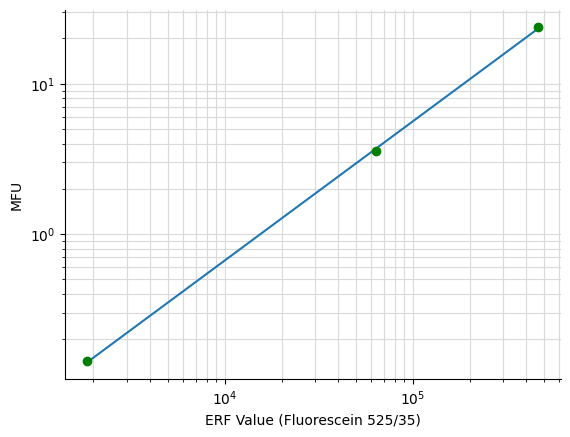

In [10]:
FITC = [1.85*(10**3), 6.34*(10**4), 4.62*(10**5)]

y = np.log(  np.reshape(beadsMeanM, np.shape(beadsMeanM)[0]*np.shape(beadsMeanM)[1])  )
x = np.log(  FITC*np.shape(beadsMeanM)[0]  )

slope, intercept, r, p, std_err = sp.stats.linregress(x, y)

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, np.log(FITC)))




fig, ax = plt.subplots()
ax.grid(True, which="both", color='0.85')
ax.set_axisbelow(True)

ax.plot( np.arange(np.min(FITC), np.max(FITC)) ,   np.exp(myfunc(np.log(np.arange(np.min(FITC), np.max(FITC)))))   )

ax.errorbar(FITC, np.mean(beadsMeanM, axis=0), yerr=np.std(beadsMeanM, axis=0), fmt='o', c='green')

ax.set_ylabel('MFU')
ax.set_xlabel('ERF Value (Fluorescein 525/35)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)
plt.show()

# Load Data

In [11]:
# 5 ug per 1 million cells

mainP = 'C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/MCT_Ab_WithAndWithoutCO2/' # Main experiment with increasing Ab concentrations

fls = os.listdir(mainP)
flsFC = [fls[i] for i in range(len(fls)) if fls[i][-3::] != 'PDF' and fls[i] != 'Plots' and fls[i] != 'Calibrate']

flsFC

['David Ab1 00219677 107.LMD',
 'David Ab1 00219695 125.LMD',
 'David Ab2 00219678 108.LMD',
 'David Ab2 00219696 126.LMD',
 'David Ab3 00219679 109.LMD',
 'David Ab3 00219697 127.LMD',
 'David Con1 00219671 101.LMD',
 'David Con1 00219689 119.LMD',
 'David Con2 00219672 102.LMD',
 'David Con2 00219690 120.LMD',
 'David Con3 00219673 103.LMD',
 'David Con3 00219691 121.LMD',
 'David Iso1 00219674 104.LMD',
 'David Iso1 00219692 122.LMD',
 'David Iso2 00219675 105.LMD',
 'David Iso2 00219693 123.LMD',
 'David Iso3 00219676 106.LMD',
 'David Iso3 00219694 124.LMD',
 'David NoCO2AB1 00219686 116.LMD',
 'David NoCO2AB2 00219684 114.LMD',
 'David NoCO2AB3 00219688 118.LMD',
 'David NoCO2Con1 00219680 110.LMD',
 'David NoCO2Con2 00219681 111.LMD',
 'David NoCO2Con3 00219682 112.LMD',
 'David NoCO2ISO1 00219683 113.LMD',
 'David NoCO2ISO2 00219687 117.LMD',
 'David NoCO2ISO3 00219685 115.LMD']

In [12]:
dats = {}
datsGt1 = {}
datsGt2 = {}
for i in range(len(flsFC)):
    dats[flsFC[i]] = FlowCal.transform.to_rfi(FlowCal.io.FCSData(mainP+flsFC[i]))
    
    datsGt1[flsFC[i]] = FlowCal.gate.high_low(dats[flsFC[i]], channels=['FS INT LIN', 'SS INT LIN'])

    datsGt2[flsFC[i]] = FlowCal.gate.density2d(datsGt1[flsFC[i]],
                                channels=['FS INT LIN', 'SS INT LIN'],
                                gate_fraction=0.9,
                                full_output=True)

c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 507286)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 1390262)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 523630)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 1386842)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data 

<Figure size 640x480 with 0 Axes>

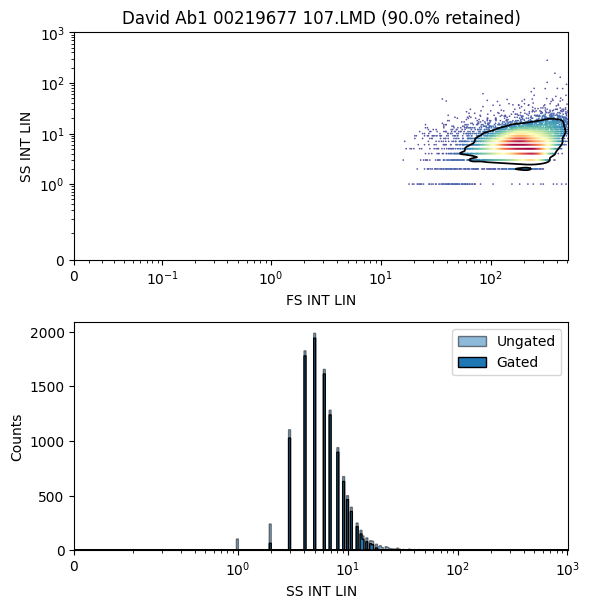

<Figure size 640x480 with 0 Axes>

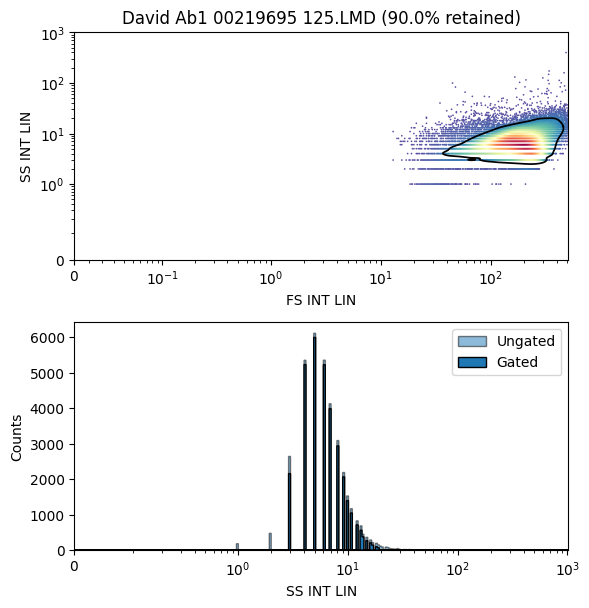

<Figure size 640x480 with 0 Axes>

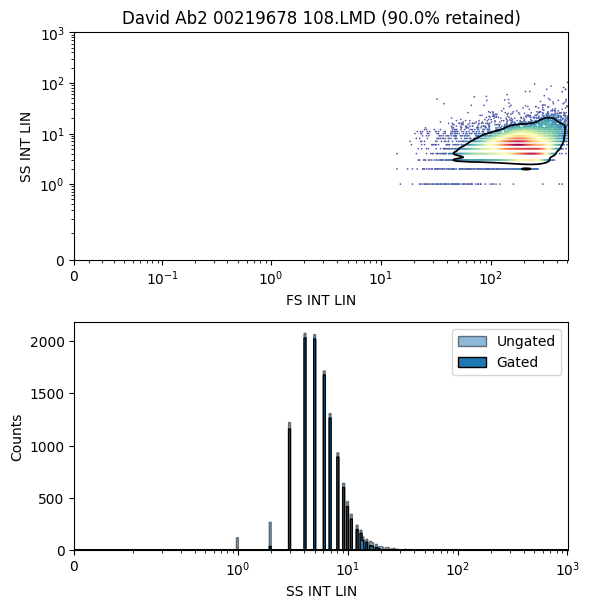

<Figure size 640x480 with 0 Axes>

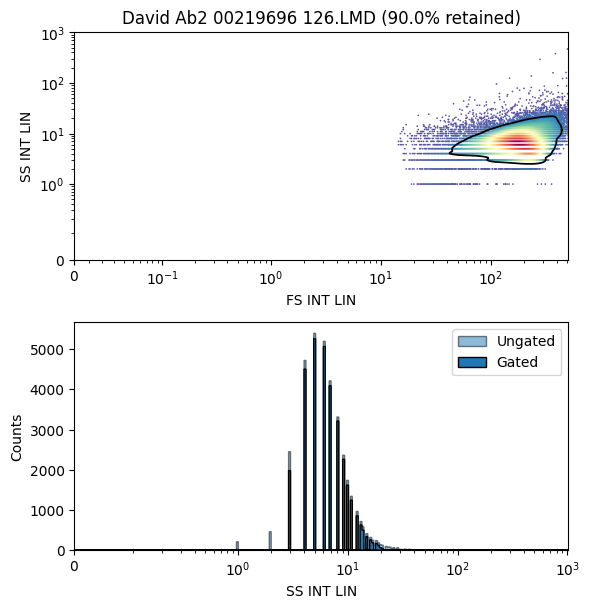

<Figure size 640x480 with 0 Axes>

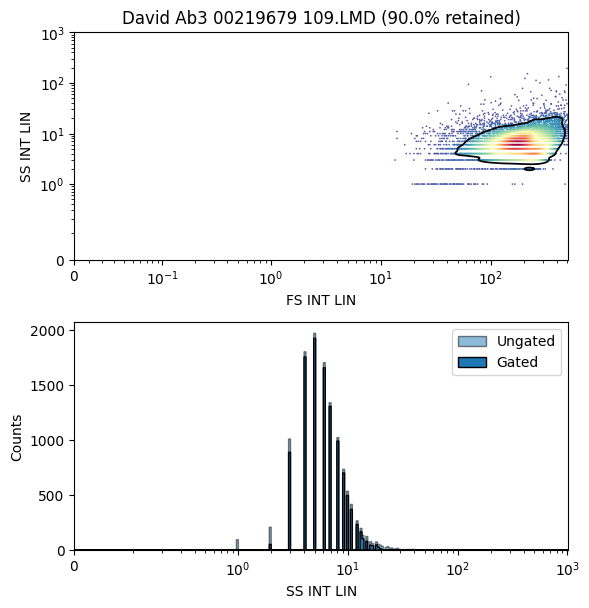

<Figure size 640x480 with 0 Axes>

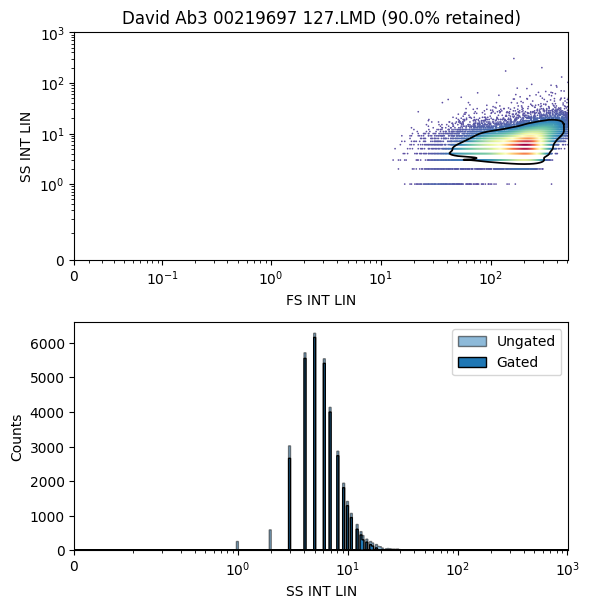

<Figure size 640x480 with 0 Axes>

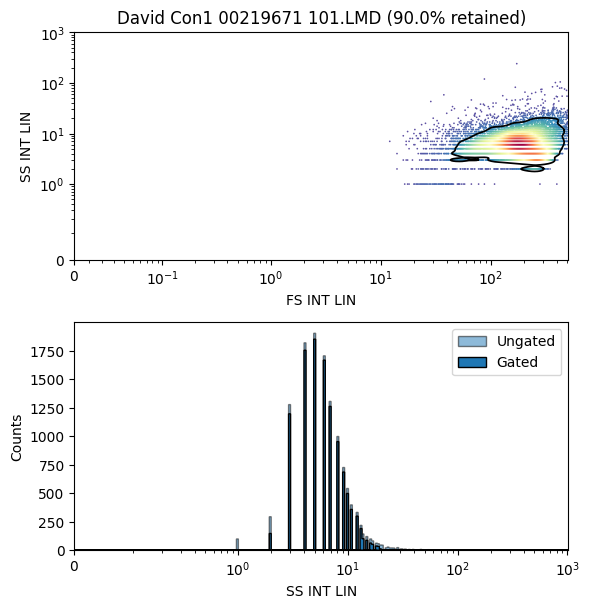

<Figure size 640x480 with 0 Axes>

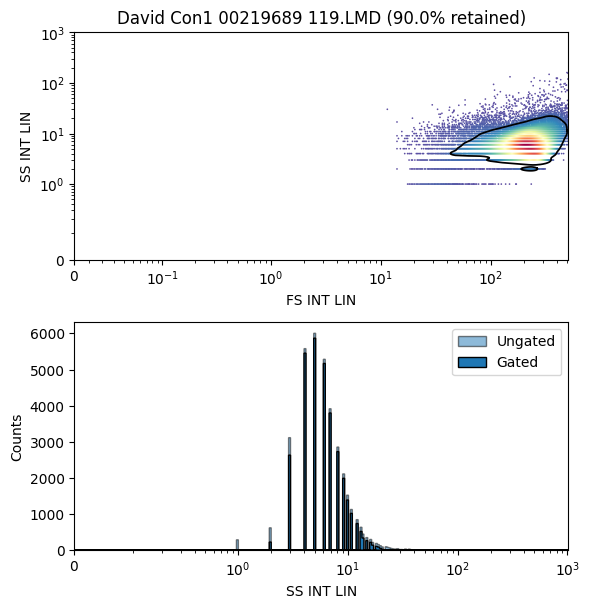

<Figure size 640x480 with 0 Axes>

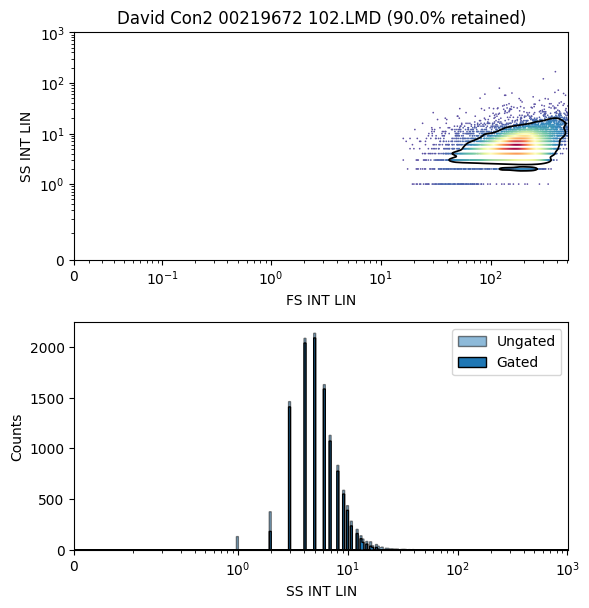

<Figure size 640x480 with 0 Axes>

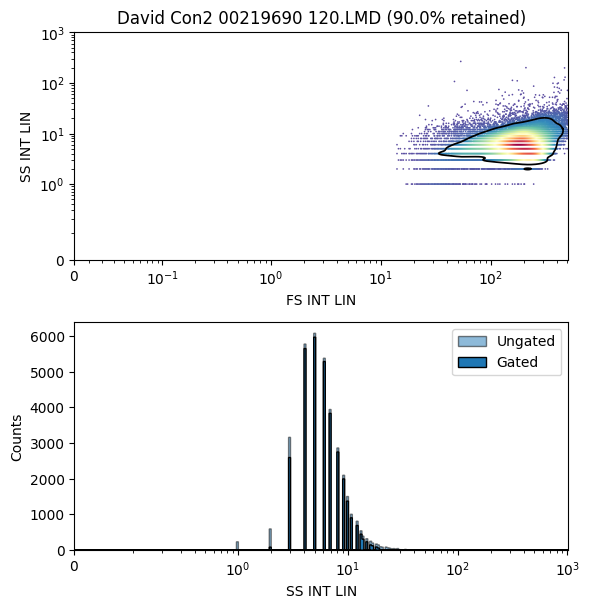

<Figure size 640x480 with 0 Axes>

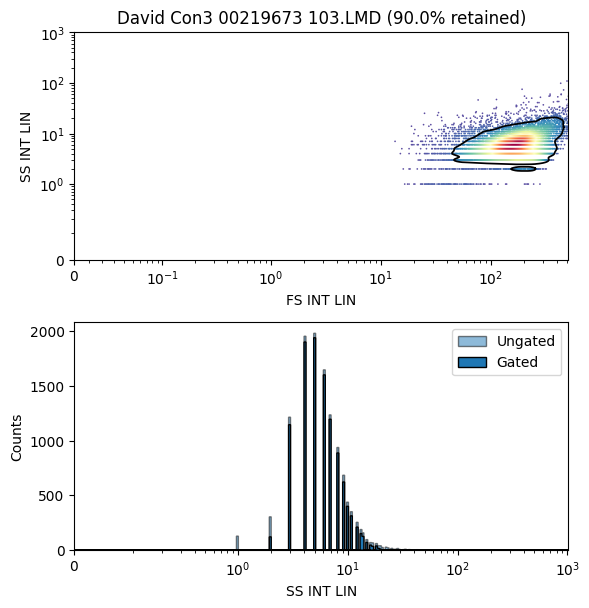

<Figure size 640x480 with 0 Axes>

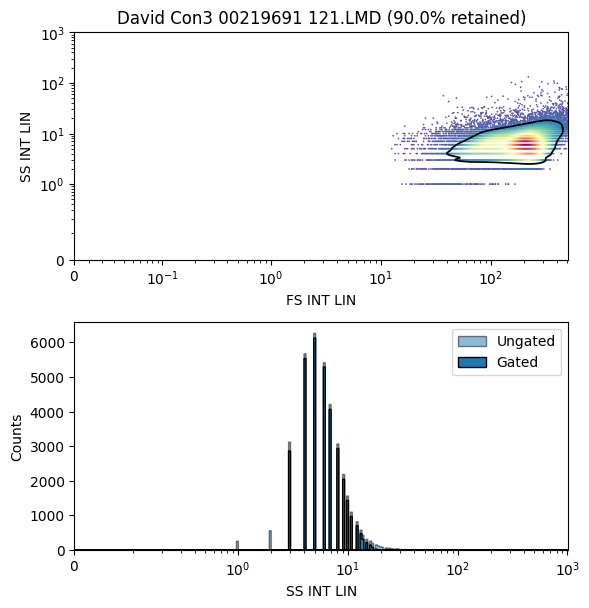

<Figure size 640x480 with 0 Axes>

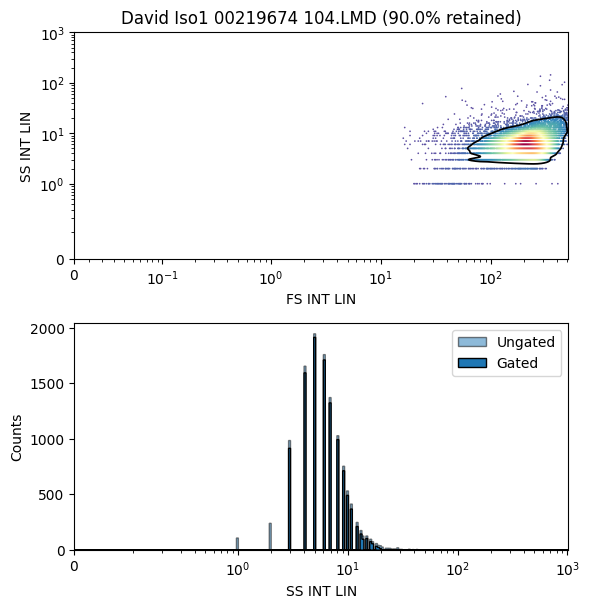

<Figure size 640x480 with 0 Axes>

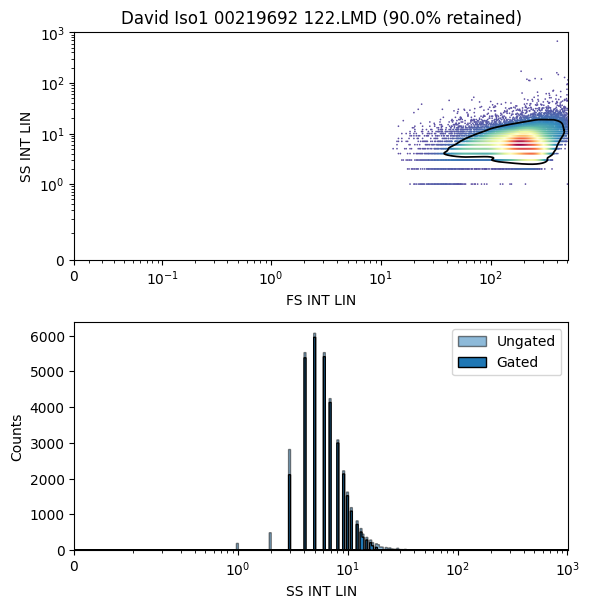

<Figure size 640x480 with 0 Axes>

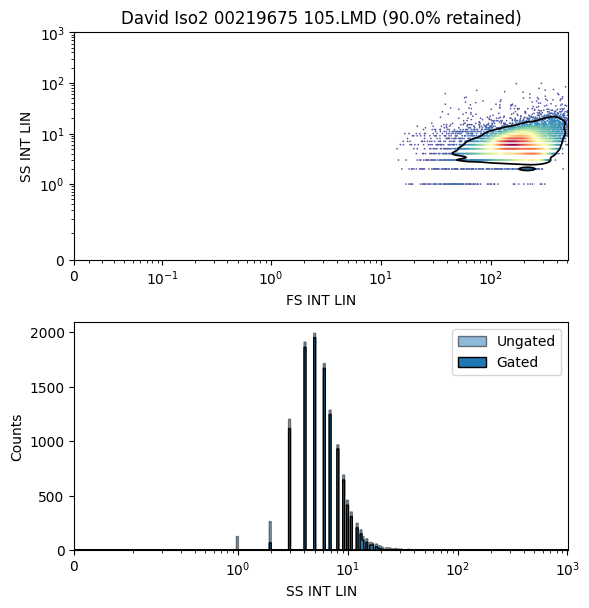

<Figure size 640x480 with 0 Axes>

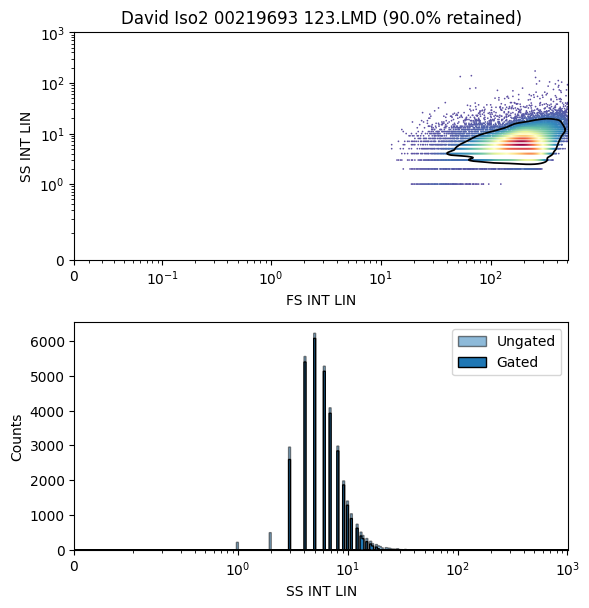

<Figure size 640x480 with 0 Axes>

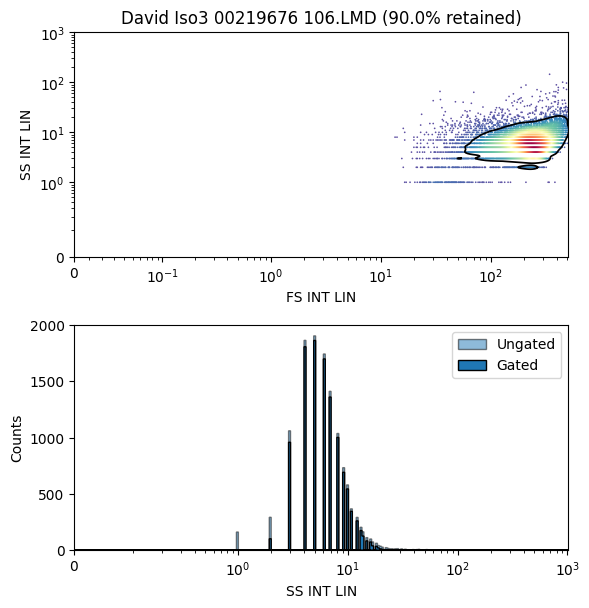

<Figure size 640x480 with 0 Axes>

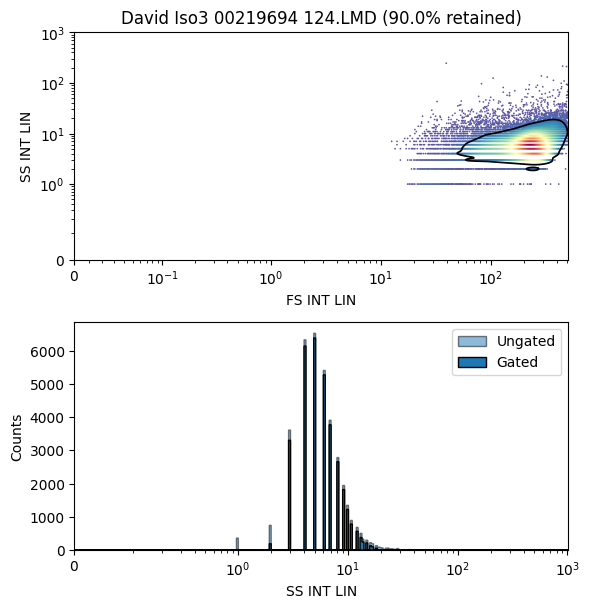

<Figure size 640x480 with 0 Axes>

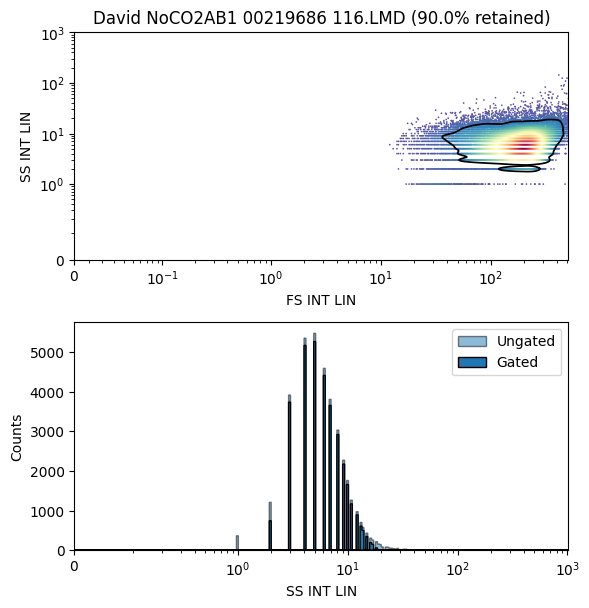

<Figure size 640x480 with 0 Axes>

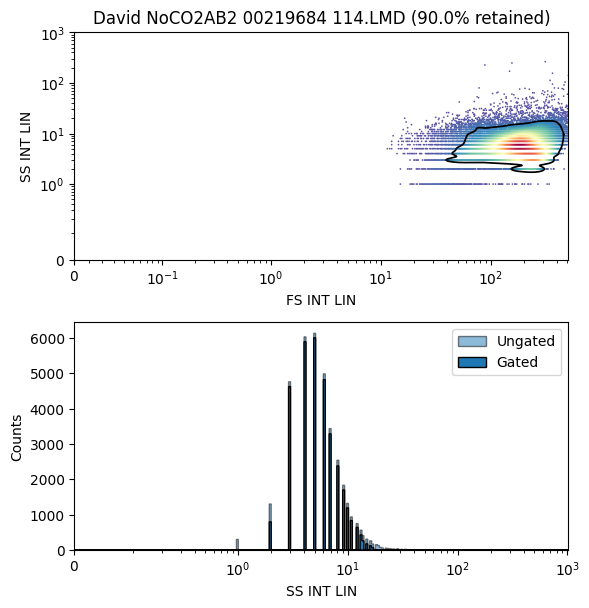

<Figure size 640x480 with 0 Axes>

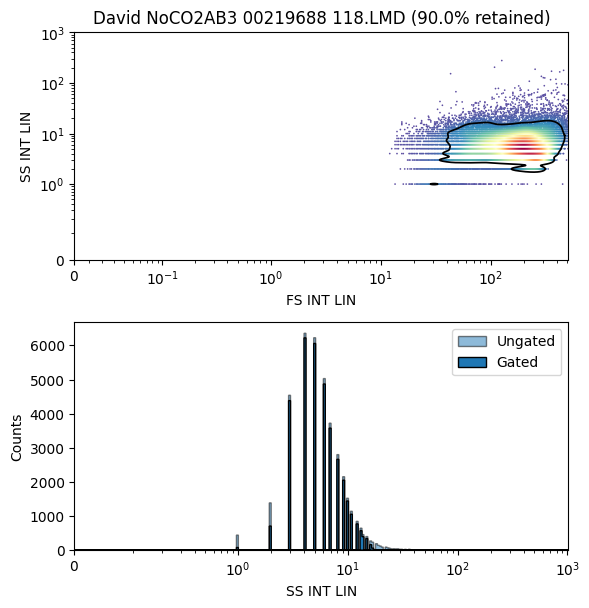

<Figure size 640x480 with 0 Axes>

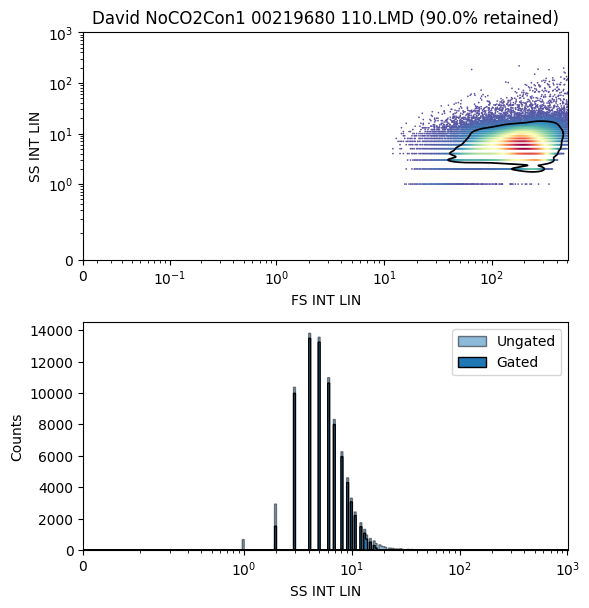

<Figure size 640x480 with 0 Axes>

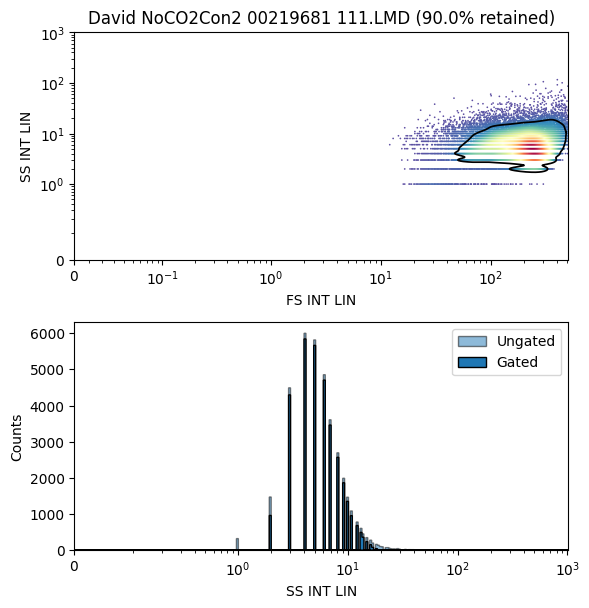

<Figure size 640x480 with 0 Axes>

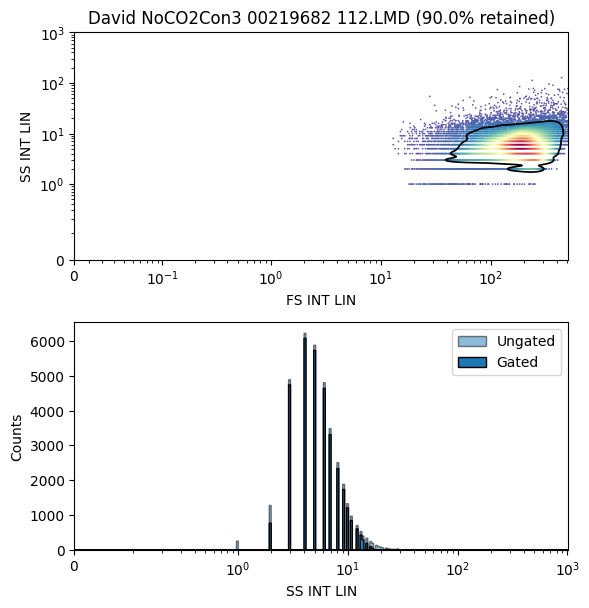

<Figure size 640x480 with 0 Axes>

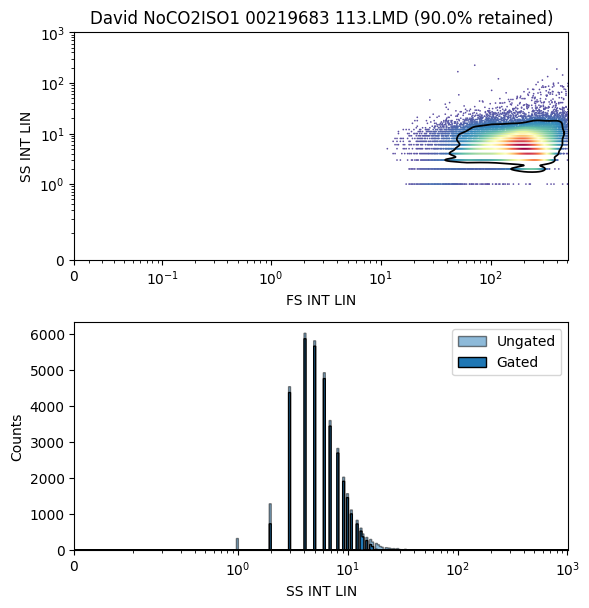

<Figure size 640x480 with 0 Axes>

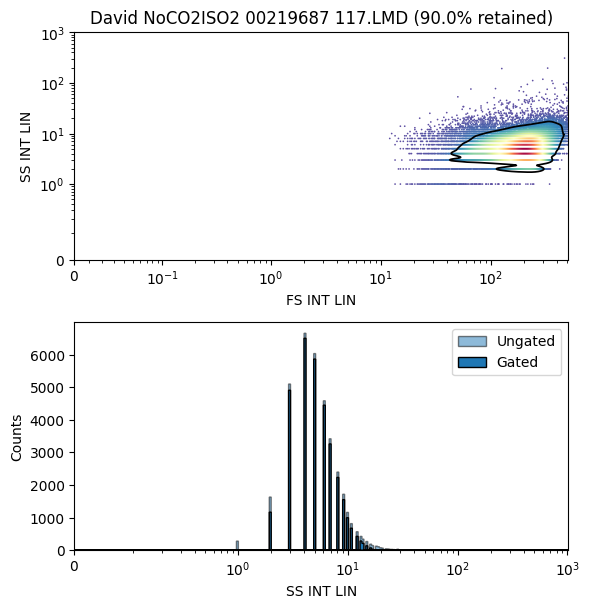

<Figure size 640x480 with 0 Axes>

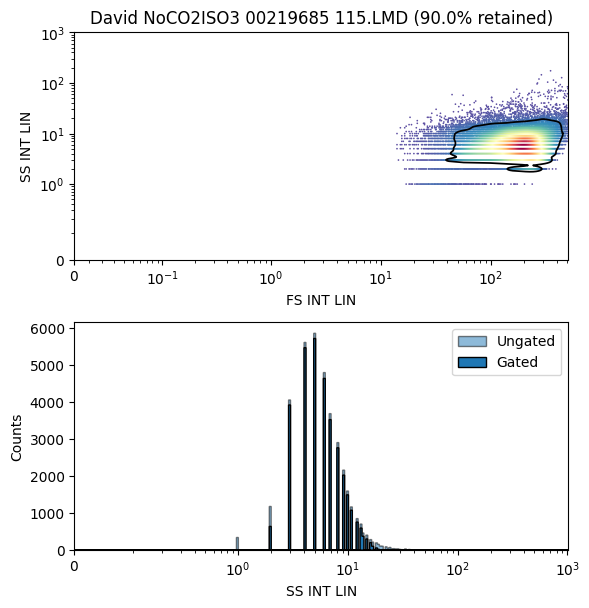

In [13]:
if os.path.isdir(mainP+'Plots') == False:
    os.mkdir(mainP+'Plots')

for i in range(len(flsFC)):

    plt.ioff()

    fig = plt.figure()
    FlowCal.plot.density_and_hist(datsGt1[flsFC[i]],
                                gated_data=datsGt2[flsFC[i]].gated_data,
                                gate_contour=datsGt2[flsFC[i]].contour,
                                density_channels=['FS INT LIN', 'SS INT LIN'],
                                density_params={'mode':'scatter'},
                                hist_channels=['SS INT LIN'])
    plt.tight_layout()
    
    
    plt.savefig(mainP+'Plots/'+flsFC[i][0:-4]+'.png')
    plt.show()

## First Check with traditional gaiting

#### Extract and Display Data

In [14]:
CnsMean = {} # Data With Means of each replicate
CnsMode = {} # Data with Modes of each replicate
CnsAllT = {} # All data of all replicates together
CnsRepT = {} # All data with replicates per separate

### Blank

In [15]:
BlankFils = [flsFC[i] for i in range(len(flsFC)) if ' Co' in flsFC[i]]
BlankNoCO2Fils = [flsFC[i] for i in range(len(flsFC)) if 'NoCO2Con' in flsFC[i]]


CnsMean['Blank'] = np.zeros(len(BlankFils))
CnsMode['Blank'] = np.zeros(len(BlankFils))
CnsAllT['Blank'] = []
CnsRepT['Blank'] = {}

CnsMean['BlankNoCO2'] = np.zeros(len(BlankFils))
CnsMode['BlankNoCO2'] = np.zeros(len(BlankFils))
CnsAllT['BlankNoCO2'] = []
CnsRepT['BlankNoCO2'] = {}

for z in range(len(BlankFils)):
    CnsMean['Blank'][z] = np.mean(datsGt2[BlankFils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['Blank'][z] = sp.stats.mode(datsGt2[BlankFils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['Blank'] = np.concatenate((CnsAllT['Blank'],  np.array(datsGt2[BlankFils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['Blank'][z] = datsGt2[BlankFils[z]].gated_data[::, 'FL1 INT LOG']
    
for z in range(len(BlankNoCO2Fils)):
    CnsMean['BlankNoCO2'][z] = np.mean(datsGt2[BlankNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['BlankNoCO2'][z] = sp.stats.mode(datsGt2[BlankNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['BlankNoCO2'] = np.concatenate((CnsAllT['BlankNoCO2'],  np.array(datsGt2[BlankNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['BlankNoCO2'][z] = datsGt2[BlankNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG']

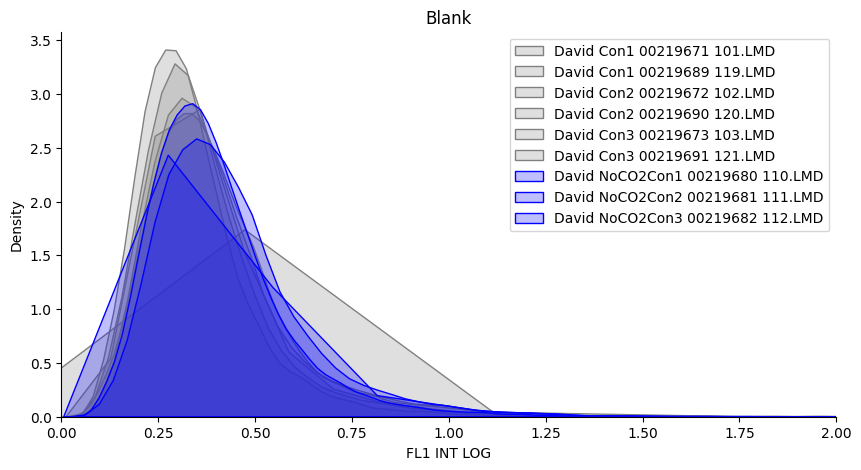

In [16]:
fig, ax = plt.subplots(figsize=(10,5))

for i in range(len(CnsRepT['Blank'])):
    sns.kdeplot(data=CnsRepT['Blank'][i], label = BlankFils[i], fill=True, color = "gray")
    
for i in range(len(CnsRepT['BlankNoCO2'])):
    sns.kdeplot(data=CnsRepT['BlankNoCO2'][i], label = BlankNoCO2Fils[i], fill=True, color = "blue")

ax.set_xlabel("FL1 INT LOG")
ax.set_title("Blank")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
ax.set_xlim(0,2)
ax.legend()
plt.show()

### Isotype

In [17]:
IsotypeFils = [flsFC[i] for i in range(len(flsFC)) if ' Iso' in flsFC[i]]
IsotypeNoCO2Fils = [flsFC[i] for i in range(len(flsFC)) if 'NoCO2ISO' in flsFC[i]]

CnsMean['Iso'] = np.zeros(len(IsotypeFils))
CnsMode['Iso'] = np.zeros(len(IsotypeFils))
CnsAllT['Iso'] = []
CnsRepT['Iso'] = {}

CnsMean['IsoNoCO2'] = np.zeros(len(IsotypeFils))
CnsMode['IsoNoCO2'] = np.zeros(len(IsotypeFils))
CnsAllT['IsoNoCO2'] = []
CnsRepT['IsoNoCO2'] = {}

for z in range(len(IsotypeFils)):
    CnsMean['Iso'][z] = np.mean(datsGt2[IsotypeFils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['Iso'][z] = sp.stats.mode(datsGt2[IsotypeFils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['Iso'] = np.concatenate((CnsAllT['Iso'],  np.array(datsGt2[IsotypeFils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['Iso'][z] = datsGt2[IsotypeFils[z]].gated_data[::, 'FL1 INT LOG']
    
for z in range(len(IsotypeNoCO2Fils)):
    CnsMean['IsoNoCO2'][z] = np.mean(datsGt2[IsotypeNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['IsoNoCO2'][z] = sp.stats.mode(datsGt2[IsotypeNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['IsoNoCO2'] = np.concatenate((CnsAllT['IsoNoCO2'],  np.array(datsGt2[IsotypeNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['IsoNoCO2'][z] = datsGt2[IsotypeNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG']

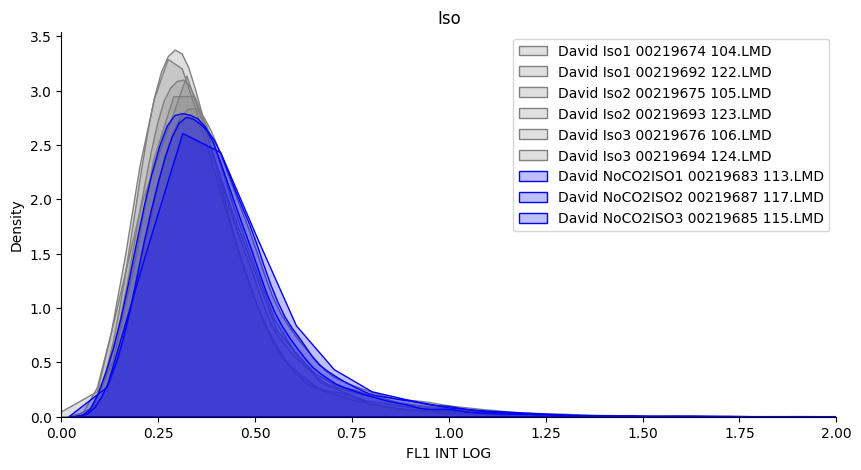

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

for i in range(len(CnsRepT['Iso'])):
    sns.kdeplot(data=CnsRepT['Iso'][i], label = IsotypeFils[i], fill=True, color='gray')
    
for i in range(len(CnsRepT['IsoNoCO2'])):
    sns.kdeplot(data=CnsRepT['IsoNoCO2'][i], label = IsotypeNoCO2Fils[i], fill=True, color='blue')

ax.set_xlabel("FL1 INT LOG")
ax.set_title("Iso")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
ax.set_xlim(0,2)

ax.legend()
plt.show()

### Fluo Sample

In [19]:
FluoFils = [flsFC[i] for i in range(len(flsFC)) if ' Ab' in flsFC[i]]
FluoNoCO2Fils = [flsFC[i] for i in range(len(flsFC)) if 'NoCO2AB' in flsFC[i]]

CnsMean['Fluo'] = np.zeros(len(FluoFils))
CnsMode['Fluo'] = np.zeros(len(FluoFils))
CnsAllT['Fluo'] = []
CnsRepT['Fluo'] = {}

CnsMean['FluoNoCO2'] = np.zeros(len(FluoFils))
CnsMode['FluoNoCO2'] = np.zeros(len(FluoFils))
CnsAllT['FluoNoCO2'] = []
CnsRepT['FluoNoCO2'] = {}

for z in range(len(FluoFils)):
    CnsMean['Fluo'][z] = np.mean(datsGt2[FluoFils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['Fluo'][z] = sp.stats.mode(datsGt2[FluoFils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['Fluo'] = np.concatenate((CnsAllT['Fluo'],  np.array(datsGt2[FluoFils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['Fluo'][z] = datsGt2[FluoFils[z]].gated_data[::, 'FL1 INT LOG']
    
for z in range(len(FluoNoCO2Fils)):
    CnsMean['FluoNoCO2'][z] = np.mean(datsGt2[FluoNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])
    CnsMode['FluoNoCO2'][z] = sp.stats.mode(datsGt2[FluoNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])[0]
    CnsAllT['FluoNoCO2'] = np.concatenate((CnsAllT['FluoNoCO2'],  np.array(datsGt2[FluoNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG'])))
    CnsRepT['FluoNoCO2'][z] = datsGt2[FluoNoCO2Fils[z]].gated_data[::, 'FL1 INT LOG']

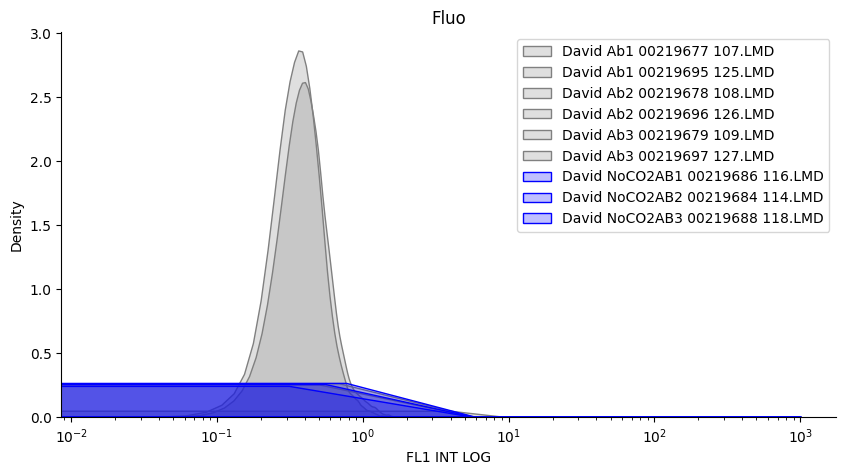

In [20]:
fig, ax = plt.subplots(figsize=(10,5))

for i in range(len(CnsRepT['Fluo'])):
    sns.kdeplot(data=CnsRepT['Fluo'][i], label = FluoFils[i], fill=True, color='gray')

for i in range(len(CnsRepT['FluoNoCO2'])):
    sns.kdeplot(data=CnsRepT['FluoNoCO2'][i], label = FluoNoCO2Fils[i], fill=True, color='blue')

ax.set_xlabel("FL1 INT LOG")
ax.set_title("Fluo")
ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.legend()
plt.show()

### All Data Together

In [21]:
# floCor = CnsAllT['Fluo']-(np.mean(CnsAllT['Iso'])-np.mean(CnsAllT['Blank']))
# floCorNoCO2 = CnsAllT['FluoNoCO2']-(np.mean(CnsAllT['IsoNoCO2'])-np.mean(CnsAllT['BlankNoCO2']))

floCor = CnsAllT['Fluo']-np.mean(CnsAllT['Blank'])
floCorNoCO2 = CnsAllT['FluoNoCO2']-np.mean(CnsAllT['BlankNoCO2'])

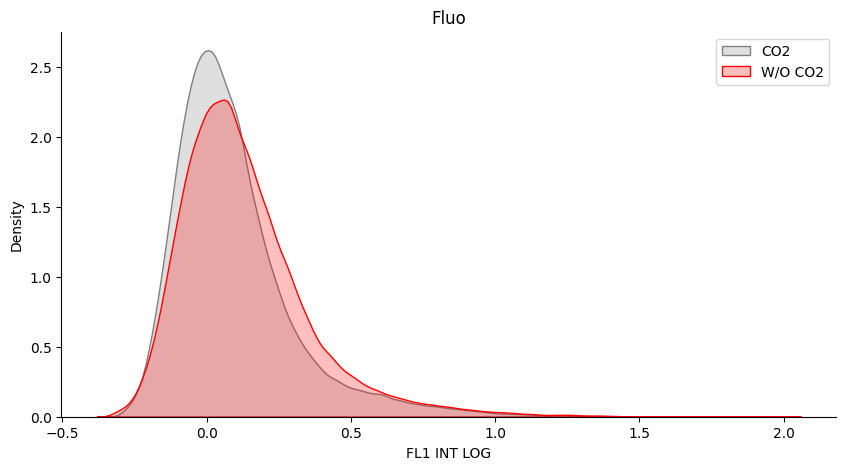

In [22]:
fig, ax = plt.subplots(figsize=(10,5))

sns.kdeplot(data=floCor[floCor < 2], label = 'CO2', fill=True, color='gray')
sns.kdeplot(data=floCorNoCO2[floCorNoCO2 < 2], label = 'W/O CO2', fill=True, color='red')

# sns.kdeplot(data=floCor, label = 'CO2', fill=True, color='gray')
# sns.kdeplot(data=floCorNoCO2, label = 'W/O CO2', fill=True, color='red')

ax.set_xlabel("FL1 INT LOG")
ax.set_title("Fluo")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
ax.legend()
plt.show()

In [23]:
ress = sp.stats.ttest_ind(a=floCor[floCor < 2], b=floCorNoCO2[floCorNoCO2 < 2])

print(ress)

TtestResult(statistic=-40.15691220471493, pvalue=0.0, df=232016.0)


In [16]:
ress.pvalue

0.0

In [17]:
np.mean(floCor[floCor < 2])

0.0954720859581122

In [18]:
np.mean(floCorNoCO2[floCorNoCO2 < 2])

0.13290950004447966

# Now gate using the green and orange channels to account for autofluorescence and only take points that express true green fluorescence

Display data with our manual gating

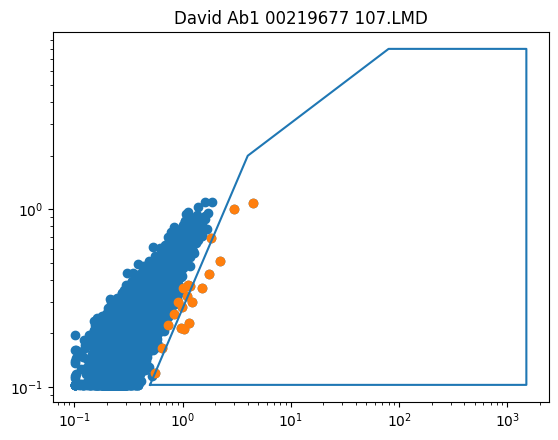

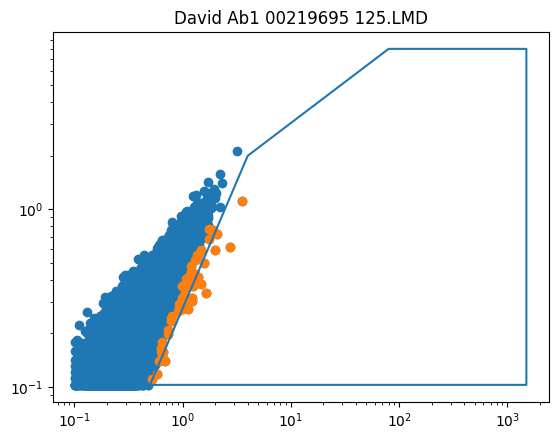

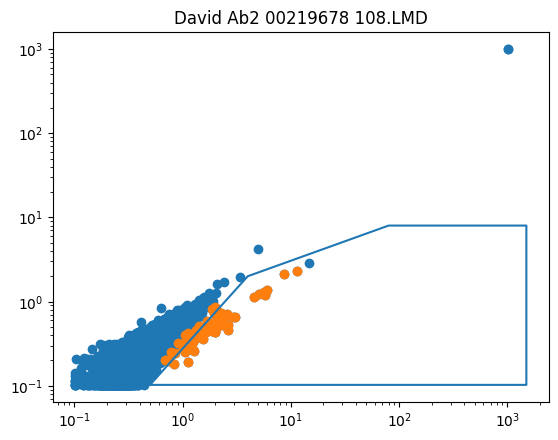

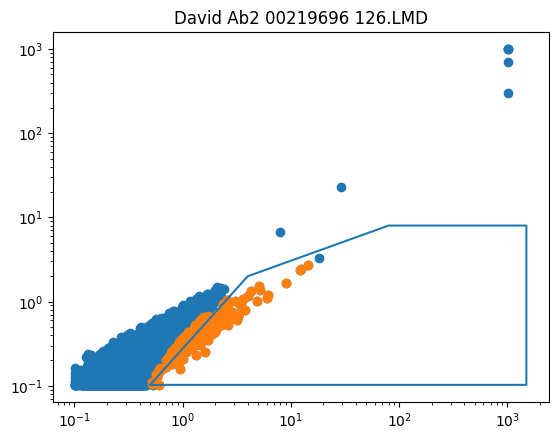

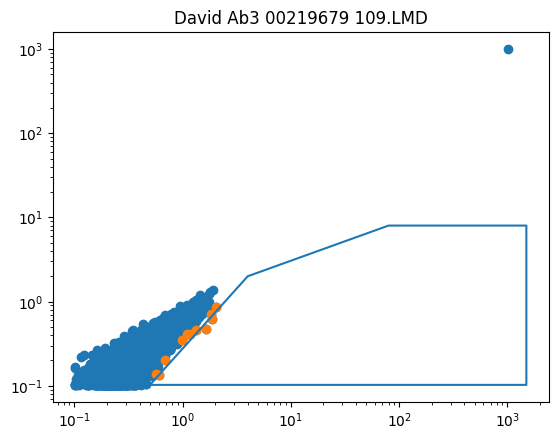

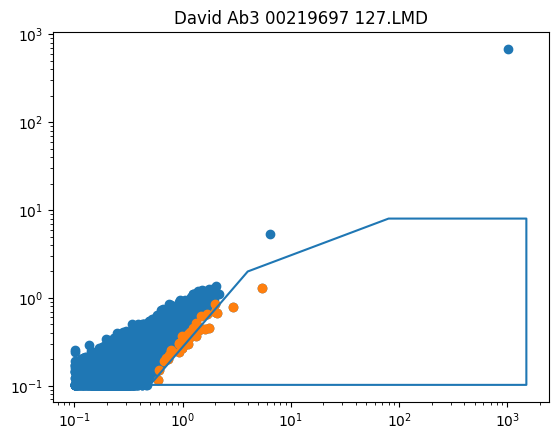

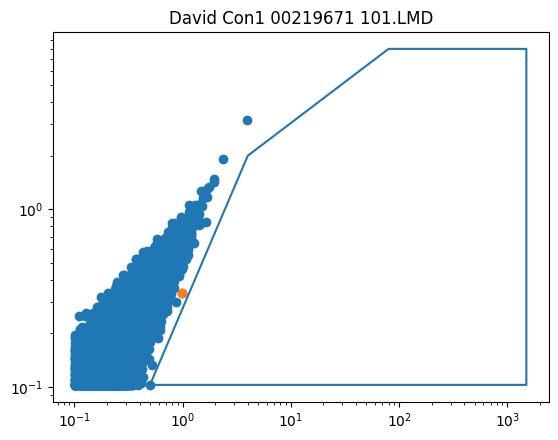

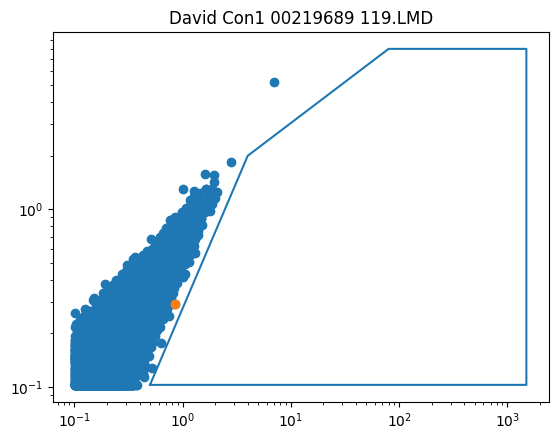

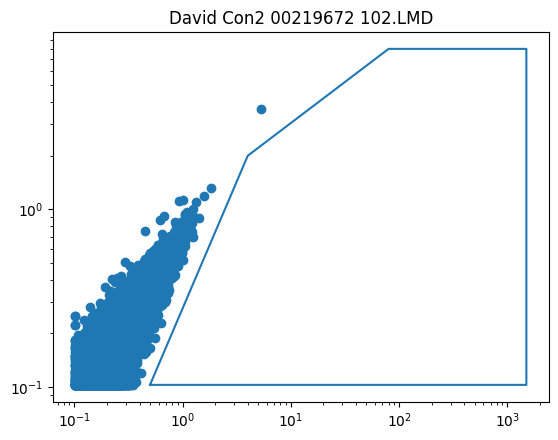

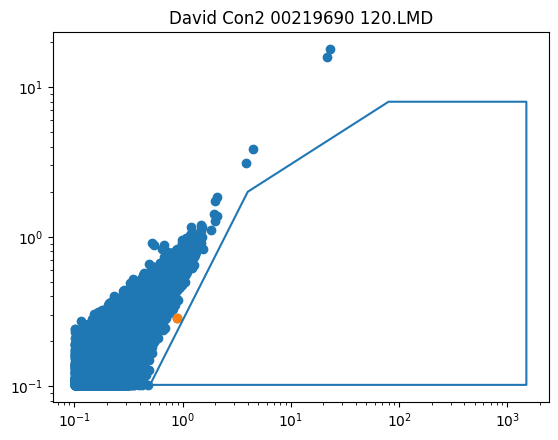

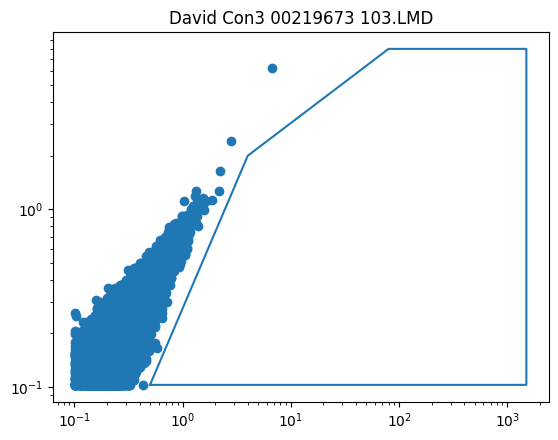

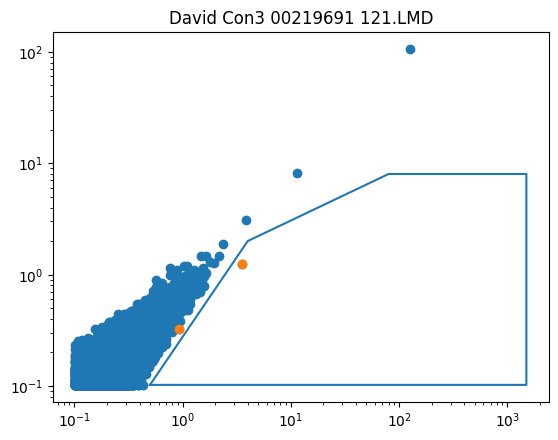

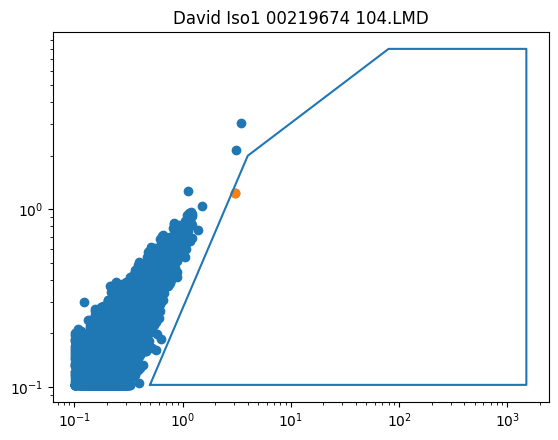

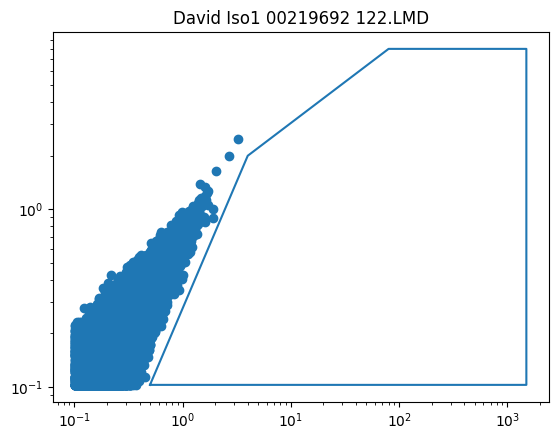

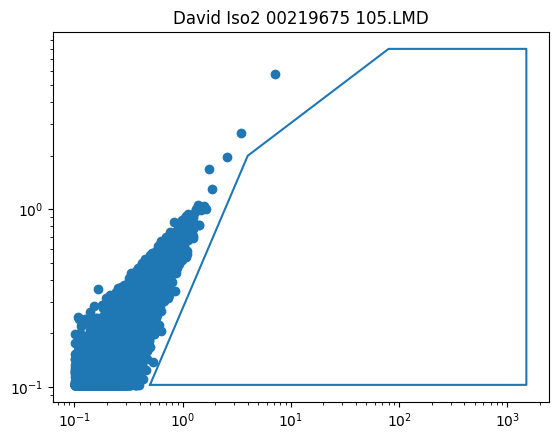

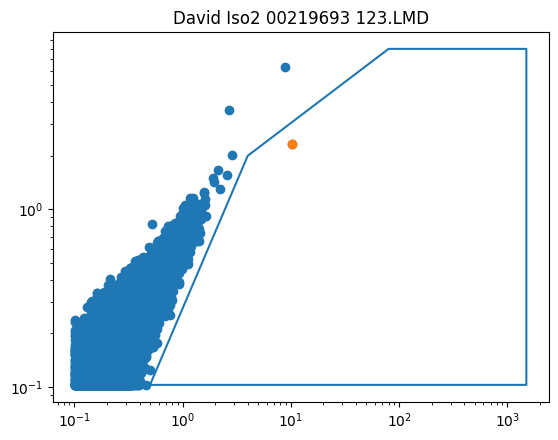

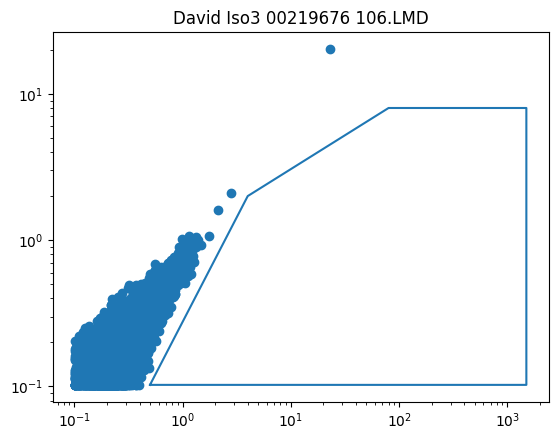

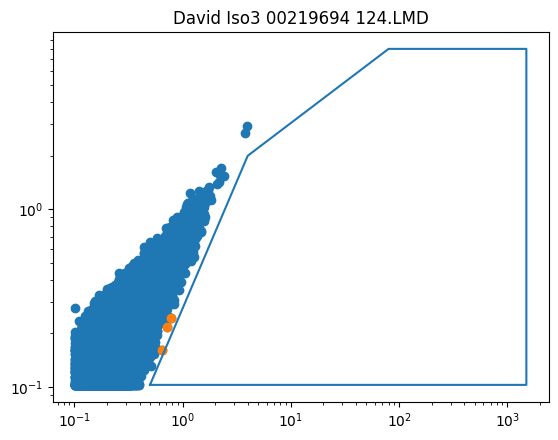

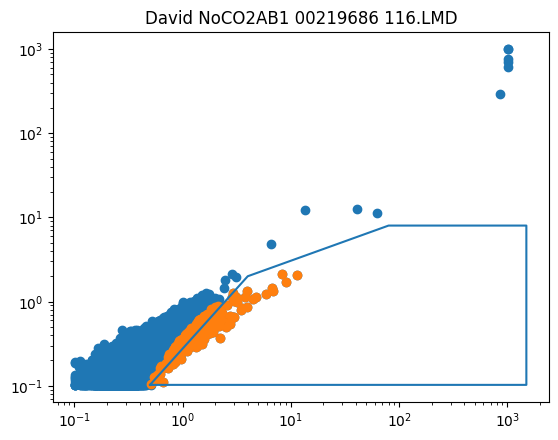

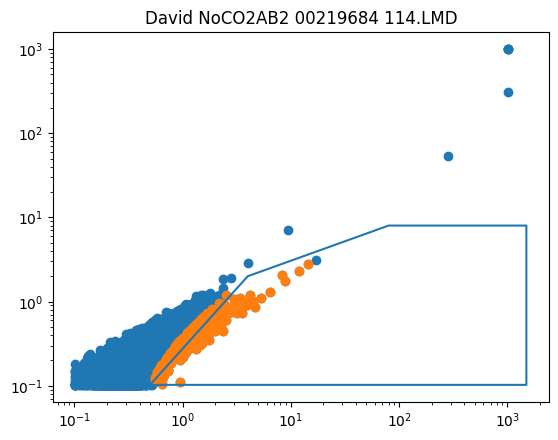

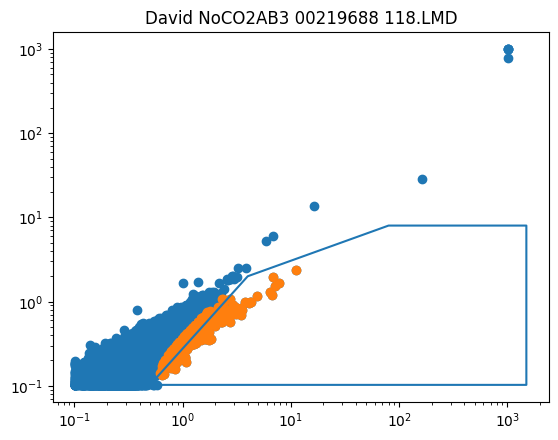

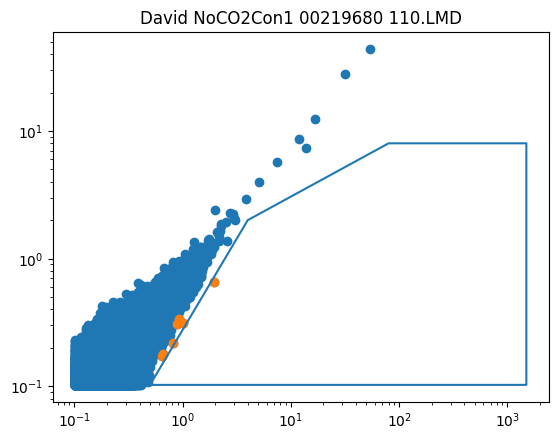

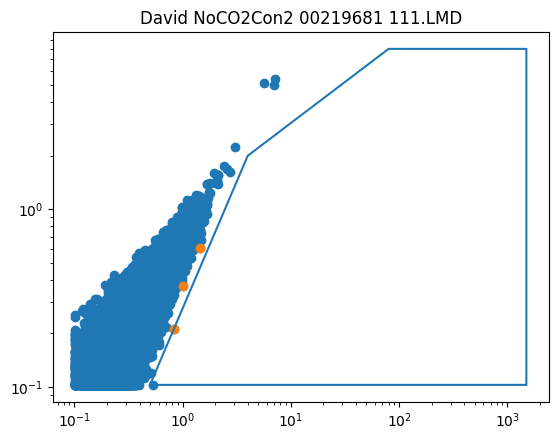

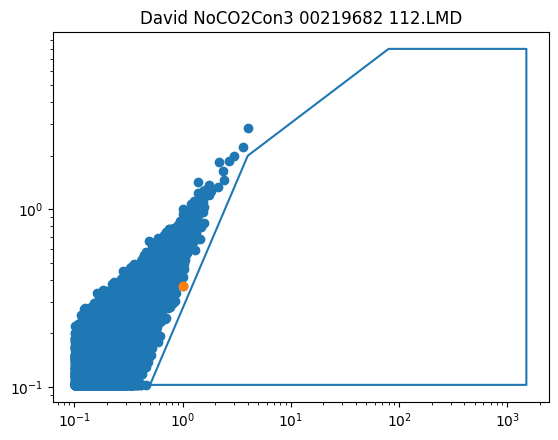

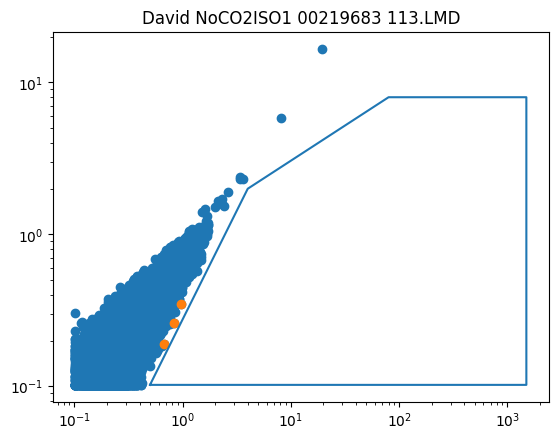

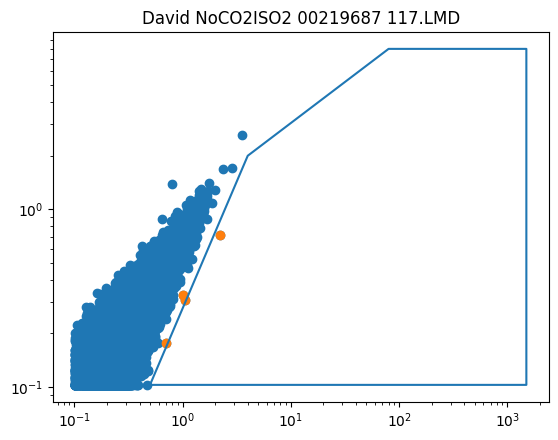

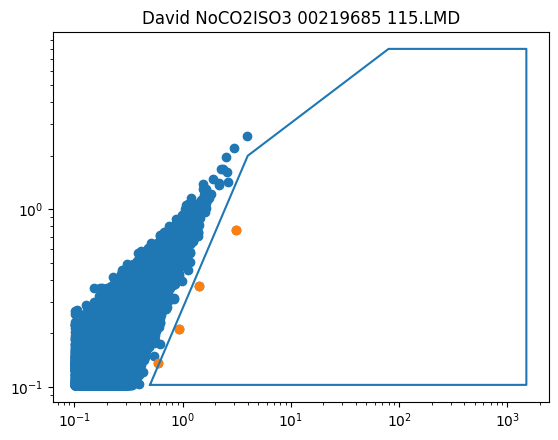

In [24]:
datsGt3 = {} # Only green fluorescence channel after gatting

# poll = [Point(0.6,0.1024), Point(5,2), Point(80,40) , Point(400,70), Point(1500,70), Point(1500, 0.1024), Point(0.6,0.1024)]
poll = [Point(0.5,0.1024), Point(4,2), Point(80,8) , Point(400,8), Point(1500,8), Point(1500, 0.1024), Point(0.5,0.1024)]

for i in range(len(flsFC)):
    gre = np.array(datsGt2[flsFC[i]].gated_data[::, 'FL1 INT LOG'])
    yel = np.array(datsGt2[flsFC[i]].gated_data[::, 'FL2 INT LOG'])
    
    fls = [point_in_polygon(Point(gre[i], yel[i]), poll) for i in range(len(gre))]

    plt.figure()
    plt.scatter(gre, yel)
    plt.scatter(gre[fls],yel[fls])
    plt.plot([poll[i].x for i in range(len(poll))],[poll[i].y for i in range(len(poll))])

    plt.title(flsFC[i])

    plt.yscale('log')
    plt.xscale('log')

    plt.show()
    
    datsGt3[flsFC[i]] = gre[fls]
    

In [25]:
Abfls = [flsFC[i] for i in range(len(flsFC)) if ' Ab' in flsFC[i]]
NOAbfls = [flsFC[i] for i in range(len(flsFC)) if '2AB' in flsFC[i]]


rtsC = []
print("W CO2")
for i in range(len(Abfls)):
    print((len(datsGt3[Abfls[i]])/len(datsGt2[Abfls[i]].gated_data[::, 'FL1 INT LOG']))*100)
    rtsC.append((len(datsGt3[Abfls[i]])/len(datsGt2[Abfls[i]].gated_data[::, 'FL1 INT LOG']))*100)
print("N("+str(np.mean(rtsC))+", "+str(np.std(rtsC))+")")
    
rtsNC = []
print("W/O CO2")
for i in range(len(NOAbfls)):
    print((len(datsGt3[NOAbfls[i]])/len(datsGt2[NOAbfls[i]].gated_data[::, 'FL1 INT LOG']))*100)
    rtsNC.append((len(datsGt3[NOAbfls[i]])/len(datsGt2[NOAbfls[i]].gated_data[::, 'FL1 INT LOG']))*100)
print("N("+str(np.mean(rtsNC))+", "+str(np.std(rtsNC))+")")    


W CO2
0.18721332958906675
0.16923597649158437
0.5974472707522405
0.6304468755794548
0.1011029411764706
0.12013677109324462
N(0.30093052744701027, 0.2233814768350735)
W/O CO2
0.9533992693575694
1.049624060150376
0.8649443156764091
N(0.9559892150614514, 0.0754174288822074)


In [26]:
i=0

datsGt3[flsFC[i]]

datsGt2[flsFC[i]].gated_data[::, 'FL1 INT LOG']

FCSData([0.30133526, 0.48537925, 0.33567961, ..., 0.47672586, 0.40546765,
         0.43965545])

# Split data in groups

In [27]:
Abfls = [flsFC[i] for i in range(len(flsFC)) if ' Ab' in flsFC[i]]
Isfls = [flsFC[i] for i in range(len(flsFC)) if ' Is' in flsFC[i]]
Cofls = [flsFC[i] for i in range(len(flsFC)) if ' Co' in flsFC[i]]

NOAbfls = [flsFC[i] for i in range(len(flsFC)) if '2AB' in flsFC[i]]
NOIsfls = [flsFC[i] for i in range(len(flsFC)) if '2Co' in flsFC[i]]
NOCofls = [flsFC[i] for i in range(len(flsFC)) if '2IS' in flsFC[i]]


####################################################################


MCTdat = {}
MCTNoCO2dat = {}

for i in range(len(Abfls)):
    MCTdat['Ab'+str(i)] = datsGt3[Abfls[i]]
    MCTdat['Is'+str(i)] = datsGt3[Isfls[i]]
    MCTdat['Cn'+str(i)] = datsGt3[Cofls[i]]

for i in range(len(NOAbfls)):
    MCTNoCO2dat['Ab'+str(i)] = datsGt3[NOAbfls[i]]
    MCTNoCO2dat['Is'+str(i)] = datsGt3[NOIsfls[i]]
    MCTNoCO2dat['Cn'+str(i)] = datsGt3[NOCofls[i]]

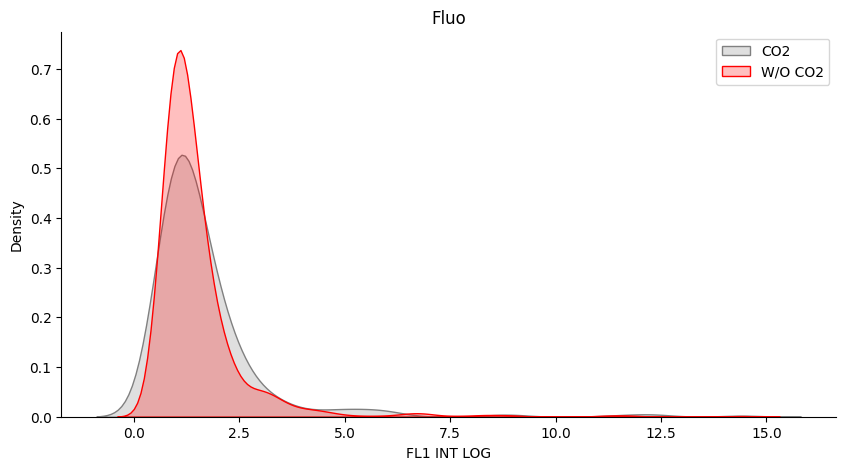

In [28]:
fig, ax = plt.subplots(figsize=(10,5))

# sns.kdeplot(data=floCor[floCor < 2], label = 'CO2', fill=True, color='gray')
# sns.kdeplot(data=floCorNoCO2[floCorNoCO2 < 2], label = 'W/O CO2', fill=True, color='red')

sns.kdeplot(data=np.concatenate([MCTdat['Ab'+str(i)] for i in range(6)]), label = 'CO2', fill=True, color='gray')
sns.kdeplot(data=np.concatenate([MCTNoCO2dat['Ab'+str(i)] for i in range(3)]), label = 'W/O CO2', fill=True, color='red')

ax.set_xlabel("FL1 INT LOG")
ax.set_title("Fluo")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
ax.legend()
plt.show()

In [32]:
ress = sp.stats.ttest_ind(a=np.concatenate([MCTdat['Ab'+str(i)] for i in range(6)]), b=np.concatenate([MCTNoCO2dat['Ab'+str(i)] for i in range(3)]))

print(ress)

TtestResult(statistic=2.188260208398555, pvalue=0.028819176110833622, df=1369.0)


In [33]:
np.mean(np.concatenate([MCTdat['Ab'+str(i)] for i in range(6)]))

1.687821093987911

In [34]:
np.mean(np.concatenate([MCTNoCO2dat['Ab'+str(i)] for i in range(3)]))

1.5167415301924472

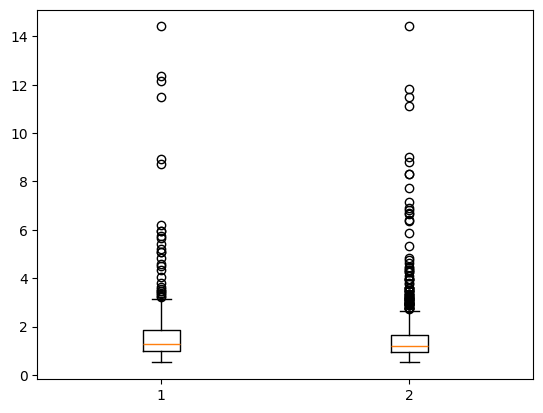

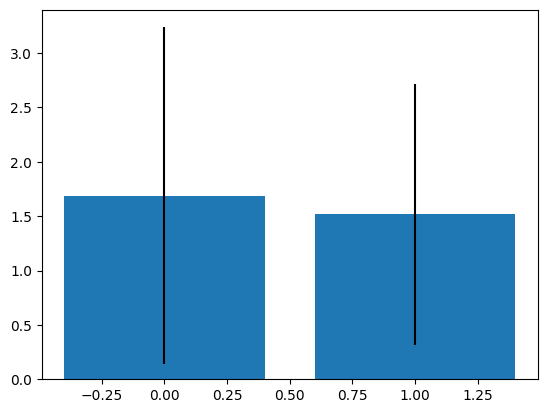

In [33]:
wc = np.concatenate([MCTdat['Ab'+str(i)] for i in range(6)])
woc = np.concatenate([MCTNoCO2dat['Ab'+str(i)] for i in range(3)])

plt.figure()
plt.boxplot([wc, woc])
plt.show()

plt.figure()
plt.bar([0,1], [np.mean(wc), np.mean(woc)], yerr = [np.std(wc), np.std(woc)])
plt.show()

# Degree of labeling 

In [29]:
DOL_Dat = pd.read_csv(r'C:\IBECPostDocDrive\2024_01_16_NCvsKR\Paper\NoCO2Asseys\MCT1\DOL_AbsData488.csv')

antinds = [k for k in range(len(DOL_Dat["Wavelength"])) if 'Anti' in DOL_Dat["Wavelength"][k]]

# DOL of Isotype just as a check that everything is working fine (should be same as for the anti LDH)
flu260 = np.array(DOL_Dat['260nm'][antinds])
flu485 = np.array(DOL_Dat['485nm'][antinds])

In [30]:
# Average DOL for Isotype Control
CF = 0.11 # Absorvance correction factor
DF = 1 # Dillution factor
eps = 210000 # Molar extinction coefficient for IgG (M-1 cm-1)
epp = 73000 # Molar extinction coefficient for fluorescent dye (M-1 cm-1)


M = ((flu260-(flu485*CF))/eps)*DF
DOL_FLU = (flu485/(epp*M))*DF

print("Anti LDH Degree of Labeling: \n")
print("     N("+str(np.mean(DOL_FLU))+", "+str(np.std(DOL_FLU))+")")

Anti LDH Degree of Labeling: 

     N(4.151352877973566, 0.13566074125754427)


# Compute ERF

In [31]:
def myfuncRev(y):
  return (y - intercept) / slope

def compERF(slope, intercept, FITC, beadsMeanM, CEX):
    
    fig, ax = plt.subplots()
    ax.grid(True, which="both", color='0.85')
    ax.set_axisbelow(True)

    ax.plot( np.arange(np.min(FITC), np.max(FITC)) ,   np.exp(myfunc(np.log(np.arange(np.min(FITC), np.max(FITC)))))   , c='b')

    ax.errorbar(FITC, np.mean(beadsMeanM, axis=0), yerr=np.std(beadsMeanM, axis=0), fmt='o', c='red')
    
    ERF = np.zeros(len(CEX))
    if len(CEX) < 10:
      for i in range(len(CEX)):
          
          ERF[i] = np.exp(myfuncRev(np.log(CEX[i])))
          
          # ax.plot([np.min(FITC), ERF[i]], 
          #         [CEX[i], CEX[i]], c='g')
          ax.arrow(x = np.min(FITC), y = CEX[i], 
                  dx=ERF[i]*0.85, dy=0, color='g',
                  length_includes_head=True,
                  head_width = CEX[i]*0.1, head_length = ERF[i]*0.05)
          
          # ax.plot([ERF[i], ERF[i]],
          #         [CEX[i], np.min(np.mean(beadsMeanM, axis=0))], c='g')
          ax.arrow(x = ERF[i], y = CEX[i], 
                  dx=0, dy=-CEX[i]+np.min(np.mean(beadsMeanM, axis=0)), color='g',
                  length_includes_head=True,
                  head_width = ERF[i]*0.1, head_length = (CEX[0])*0.01)
          
          ax.scatter([ERF[i]], CEX[i], c='g',zorder=10)
          
    else:
      for i in range(len(CEX)):
          ERF[i] = np.exp(myfuncRev(np.log(CEX[i])))
    
      ax.arrow(x = np.min(FITC), y = np.mean(CEX), 
                  dx=np.mean(ERF)*0.85, dy=0, color='g',
                  length_includes_head=True,
                  head_width = np.mean(CEX)*0.1, head_length = np.mean(ERF)*0.05)
      ax.arrow(x = np.mean(ERF), y = np.mean(CEX), 
                    dx=0, dy=-np.mean(CEX)+np.min(np.mean(beadsMeanM, axis=0)), color='g',
                    length_includes_head=True,
                    head_width = np.mean(ERF)*0.1, head_length = np.mean(CEX)*0.01)  
      
      ax.scatter([np.mean(ERF)], np.mean(CEX), c='g',zorder=10)
      ax.set_title('Mean ERF')
    

    ax.set_ylabel('MFU')
    ax.set_xlabel('ERF Value (APC 660/20)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.spines[['right', 'top']].set_visible(False)
    plt.show()
    
    return(ERF)

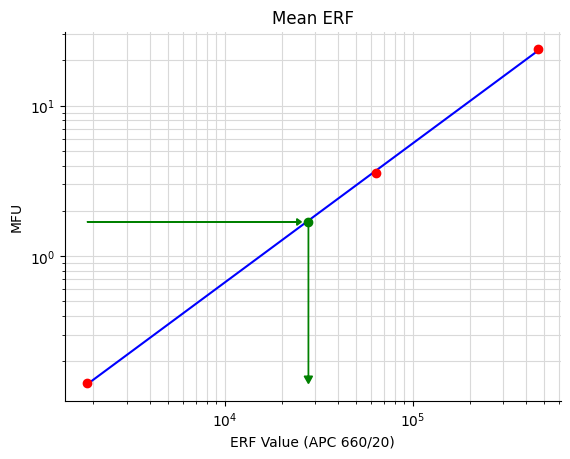

[ 36196.2647783   13955.51787182  18146.15158989  15836.28906264
  15232.06612388  24058.6034531   17453.79740278  11050.40850231
  14794.07660965  28109.22230098  17796.60792089  78805.3745346
  29509.8556551    9550.44411818  12539.66100794   8095.08662671
  15683.02263967  17284.87644633  19050.34256656  49893.53094279
  15991.05332163  26259.30775281  17624.36918326  46158.85547045
  11050.40850231  10323.16278798  19236.51700044  15380.92545685
  32841.8222573   33814.12854964  16625.383632     7636.24044094
   9366.47688629   8921.91354816   9366.47688629  19236.51700044
  13820.45388704   9929.2894675   10943.46068286  12061.21869135
  15380.92545685  18683.38174827   8665.36893043  15232.06612388
  23825.76000865  17117.59033695  28109.22230098  25504.23609325
  15380.92545685  17453.79740278  19236.51700044   9643.77832048
  60606.22866864  19806.0282284   18865.96996198  22257.74721949
  11828.88719048  20392.40025495  17284.87644633   9550.44411818
  21617.73818767  14368.68

In [34]:
ERFall = compERF(slope, intercept, FITC, beadsMeanM, wc)
print(ERFall)

NigG = ERFall/np.mean(DOL_FLU)
Nenz = NigG*2

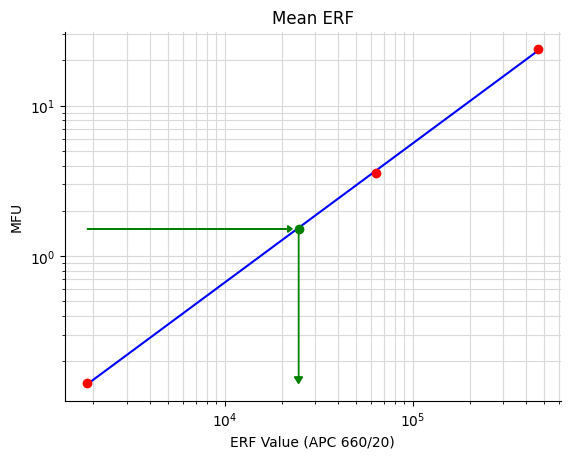

[ 25012.95593311  28941.41649233  28941.41649233  13686.69707554
  34144.58592686  13820.45388704  15836.28906264  14794.07660965
  23140.66364894  27300.95738662  14509.10291746  20792.92795306
  16464.48021141  23825.76000865  14794.07660965  15380.92545685
  16147.33005465 216678.36143235  16787.85952317  13955.51787182
  21617.73818767  25012.95593311  42703.73128702  12539.66100794
  18323.48958197  61198.51882155  25257.40155891  25012.95593311
  17117.59033695 152673.65624922  24770.87609556  50381.12846734
  22042.33278205  34144.58592686  14938.65557603  13554.23478626
  16625.383632   120891.69922545  16464.48021141  11050.40850231
  28661.31631459  22257.74721949  18683.38174827  12179.09009203
  21201.32242679  30680.4474554   26515.93367634  22475.26685062
  13164.49037067  21201.32242679  15683.02263967  20392.40025495
  16305.13404274  28941.41649233  12910.90689089  14938.65557603
  35155.46149539  30980.28011805 104482.05761477  23595.17006447
  31897.4740868   18683.3

In [35]:
ERFallNC = compERF(slope, intercept, FITC, beadsMeanM, woc)
print(ERFallNC)

NigG = ERFallNC/np.mean(DOL_FLU)
NenzNC = NigG*2

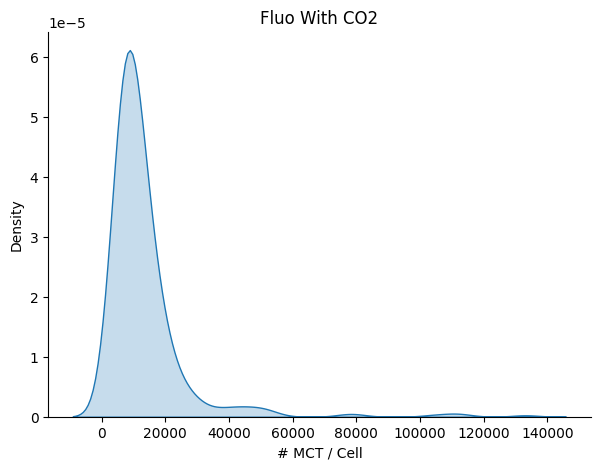

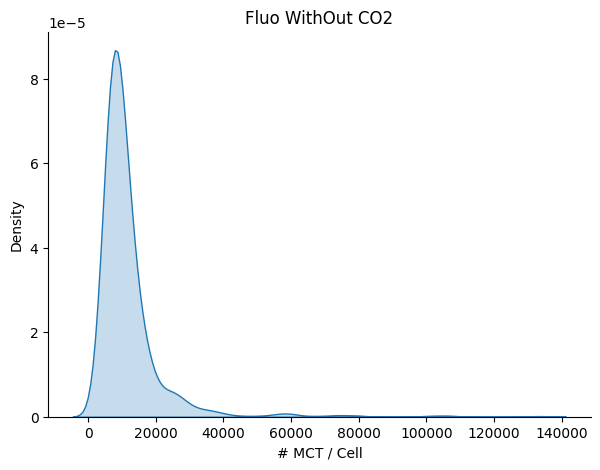

In [36]:
fig, ax = plt.subplots(figsize=(7,5))

sns.kdeplot(data=Nenz, fill=True)

ax.set_xlabel("# MCT / Cell")
ax.set_title("Fluo With CO2")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
# ax.legend()
plt.show()



fig, ax = plt.subplots(figsize=(7,5))

sns.kdeplot(data=NenzNC, fill=True)

ax.set_xlabel("# MCT / Cell")
ax.set_title("Fluo WithOut CO2")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
# ax.legend()
plt.show()

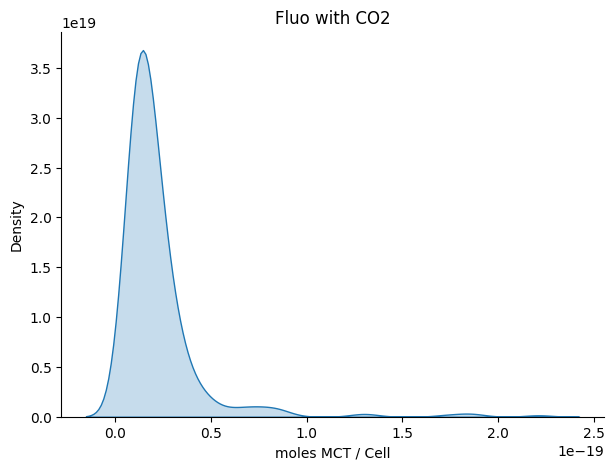

In [37]:
moleLDH = Nenz/(6.023*10**23) # Moles of LDH

fig, ax = plt.subplots(figsize=(7,5))

sns.kdeplot(data=moleLDH, fill=True)

ax.set_xlabel("moles MCT / Cell")
ax.set_title("Fluo with CO2")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
# ax.legend()
plt.show()

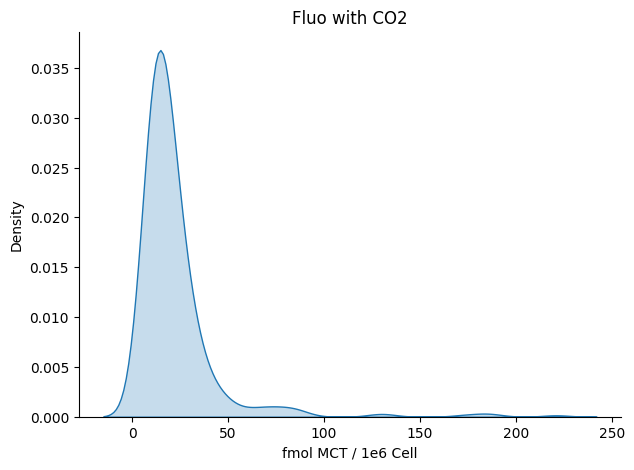

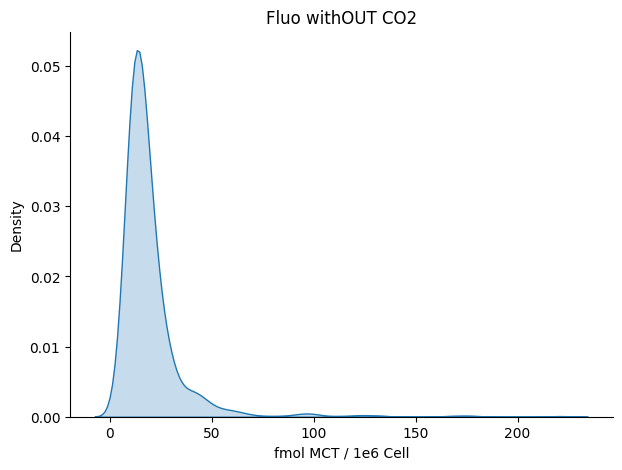

In [38]:
moleLDH2 = ((Nenz/(6.023*10**23))*1e6)*1e15 # Moles of LDH

fig, ax = plt.subplots(figsize=(7,5))

sns.kdeplot(data=moleLDH2, fill=True)

ax.set_xlabel("fmol MCT / 1e6 Cell")
ax.set_title("Fluo with CO2")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
# ax.legend()
plt.show()



moleLDH2NC = ((NenzNC/(6.023*10**23))*1e6)*1e15 # Moles of LDH

fig, ax = plt.subplots(figsize=(7,5))

sns.kdeplot(data=moleLDH2NC, fill=True)

ax.set_xlabel("fmol MCT / 1e6 Cell")
ax.set_title("Fluo withOUT CO2")
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xscale('log')
# ax.legend()
plt.show()

# Save Results for Julia Plots of Supplementary Data

In [26]:
MCTFlu = {}
MCTFlu['CO2'] = wc
MCTFlu['NoCO2'] = woc



In [27]:
with open('C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/ProcessedData.pkl', 'wb') as f:
    pickle.dump(MCTFlu, f)

In [52]:
MCTFlu2 = {}
MCTFlu2['CO2'] = moleLDH2
MCTFlu2['NoCO2'] = moleLDH2NC

In [54]:
with open('C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/ProcessedData_femtomolPer1Mil.pkl', 'wb') as f:
    pickle.dump(MCTFlu2, f)

In [52]:
pd.DataFrame(moleLDH2, columns=['MCT1']).to_csv('E:/IBEC/KineticRates/NoCO2Assays/ProcessedData_MCT1_femtomolPer1Mil.csv', index=False)
pd.DataFrame(moleLDH2NC, columns=['MCT1']).to_csv('E:/IBEC/KineticRates/NoCO2Assays/ProcessedData_MCT1_NoCO2_femtomolPer1Mil.csv', index=False)